# Seção 1
``Análise e Normalização Relacional de Contratos e Acordos de Telecomunicações (Anatel)``

---

# Seção 2
## Membros

**Autores**: **Bruna Gomes** - 2023061070,

**Carlos Eduardo Oliveira** - 2021020058,

**Emanuel Figueiredo** - 2019092470, 

**Gabriel Veloso** - 2024421649, 

**Victoria Reis** - 2020104630.

---

# Seção 3

## Bibliotecas utilizadas

In [ ]:
import pandas as pd
import numpy as np
import unicodedata
import re

import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo configurações visuais para os gráficos do relatório
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 5)

# Função auxiliar para executar e exibir as consultas de forma padronizada
def executar_consulta(sql_query, titulo):
    conn = sqlite3.connect('contratos.db')
    df = pd.read_sql_query(sql_query, conn)
    conn.close()
    print(f"\n{"="*20} {titulo} {"="*20}\n")
    return df

BASE_DADOS  = Path('Dados - Contratos Normalizados')
SCHEMA_SQL  = Path('schema.sql')
INSERTS_SQL = Path('inserts.sql')
DATABASE_SQL = Path('database.sql')
DATABASE_DB  = Path('contratos.db')

## Análise Exploratória de Dados (EDA)
Esta seção tem como objetivo realizar uma Análise Exploratória de Dados (EDA) do conjunto de dados "**Competição – Empresas Credenciadas de Rede Virtual**", disponibilizado pela Anatel. A análise busca compreender as características da base de dados, identificar padrões, inconsistências e anomalias, bem como gerar insights que auxiliem no processo de modelagem e normalização relacional dos dados.

``[https://dados.gov.br/dados/conjuntos-dados/empresas-credenciadas-de-rede-virtual-do-servico-movel-pessoal-telefonia-movel]``

### Funções de tratamento dos dados

In [104]:
pattern_process_anatel = re.compile(r'\b\d{5}\.\d{6}/(?:19|20)\d{2}-\d{2}\b')
cnpj_pattern = re.compile(
    r'\b\d{2}[\.\s/-]?\d{3}[\.\s/-]?\d{3}[\.\s/-]?\d{4}[\.\s/-]?\d{2}\b'
)

# normalizacao de texto
def normalizar_texto(texto:str)->str:
    if pd.isna(texto):
        return texto
    novo_texto = str(texto).strip()
    novo_texto = re.sub(r'\s+', ' ', novo_texto)
    return novo_texto

# filtrando processos validos
def filtrar_processos_validos(texto:str)->str:
    if pd.isna(texto):
        return np.nan
    matches = pattern_process_anatel.findall(texto)
    if len(matches) >= 1:
        return matches[0]
    else: 
        return np.nan

# extrair quais cnpjs sao validos  
def extract_valid_cnpjs(texto:str)->str:
    if pd.isna(texto): 
        return texto
    texto = str(texto)
    candidatos = cnpj_pattern.findall(texto)
    if len(candidatos) > 0:
        numeros = re.sub(r'\D', '', candidatos[0])
        return numeros
    return np.nan

# formatacao de cnpj
def format_cnpj(texto_cnpj:str)->str:
    if pd.isna(texto_cnpj): 
        return texto_cnpj
    texto_cnpj = str(texto_cnpj)
    cnpj = re.sub(r'\D', '', texto_cnpj)

    if len(cnpj) != 14:
        return np.nan

    return (
        f"{cnpj[:2]}.{cnpj[2:5]}.{cnpj[5:8]}/{cnpj[8:12]}-{cnpj[12:]}"
    )

# limpeza de caracteres
def limpar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(
        c for c in texto
        if unicodedata.category(c) != 'Mn'
    )

    texto = re.sub(r'[^a-z0-9\s]', '', texto)

    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# limpeza especifica para casos de informe sei
def limpeza_sei(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).lower()
    
    if texto.find('/') > -1: 
        texto = texto[:texto.find('/')]
    if texto.find(' ') > -1:
        texto = texto[:texto.find(' ')]
    texto = re.sub(r'[a-zA-Z///*]', '', texto).strip()
    if not texto: 
        return '0'
    else: 
        return texto

# aplicacao de limpeza de caracteres no df
def tratar_strings_df(df, exceptions:list[str]=[]):
    df = df.copy()

    colunas_texto = df.select_dtypes(include=['object', 'string']).columns

    for coluna in colunas_texto:
        if coluna not in exceptions:
            df[coluna] = df[coluna].apply(limpar_texto)

    return df

# limpeza de coluna de datas
def coluna_data(df, list_columns):
    for col in df.columns:
        if col in list_columns:
            df[col] = pd.to_datetime(
                df[col],
                format='%d/%m/%Y',
                errors='coerce'
            )

    return df

# limpeza para colunas de cnpj
def tratar_cnpj(df, cnpj_colunas):
    for col in df.columns:
        if col in cnpj_colunas:
            df[col] = (df[col]
                       .fillna(0)
                       .astype(float)
                       .astype(int)
                       .astype(str)
                       .str.zfill(14))
            
    return df

In [105]:
sei_invalido = [
    'NÃO APLICÁVEL',
    'COM PENDÊNCIA',
    'DESNECESSÁRIO',
    'NÃO INFORMADO',
    'NÃO SE APLICA',
    'PRESTAÇÃO IRREGULAR',
    'NÃO HOUVE',
    'ARQUIVO NÃO ABRE',
]

modalidades_stfc = [
    'LDI', 'LDN', 'LOCAL'
]
modalidades_stfc_invalida = 'INDEFINIDA'

O conjunto de dados analisado é composto por diferentes bases, em que cada uma representa uma versão específica de contratos ou acordos regulados pela Agência Nacional de Telecomunicações (Anatel). Esses contratos são agrupados em quatro categorias principais: **Interconexão**, **Comunicação**, **MVNO (Mobile Virtual Network Operator)** e **RAN Sharing**. Cada categoria possui características próprias, refletindo diferentes formas de relacionamento e compartilhamento de recursos entre as empresas do setor de telecomunicações.

Nesta análise, utilizaremos a linguagem Python para explorar individualmente cada conjunto de dados, buscando compreender sua estrutura, identificar padrões, verificar a qualidade das informações e levantar aspectos relevantes para a modelagem e normalização relacional dos dados.

> As categorias de contratos podem ser resumidas da seguinte forma:
>
> * **Interconexão:** contratos que estabelecem a interligação entre redes de diferentes prestadoras de telecomunicações, permitindo que usuários de uma rede possam se comunicar com usuários de outra rede.
>
> * **Comunicação:** acordos relacionados ao compartilhamento ou fornecimento de serviços de comunicação entre operadoras, abrangendo aspectos operacionais e comerciais necessários para a prestação dos serviços.
>
> * **MVNO (Mobile Virtual Network Operator):** contratos que permitem que uma empresa atue como operadora móvel virtual, oferecendo serviços de telefonia móvel aos seus clientes sem possuir infraestrutura própria de rede, utilizando a rede de uma operadora hospedeira.
>
> * **RAN Sharing (Radio Access Network Sharing):** acordos de compartilhamento da infraestrutura de acesso rádio entre operadoras, possibilitando o uso conjunto de antenas, estações rádio-base e outros elementos da rede móvel, com o objetivo de reduzir custos e ampliar a cobertura dos serviços.
>

### **Credenciadas Vigentes** 



In [106]:
df_empresas_cred = pd.read_csv(
    r'Dados - Contratos/empresas_credenciadas_vigentes.csv',
    sep=';'
)

print(df_empresas_cred.shape)

(196, 2)


### **Contratos - Compartilhamento**

Esse dataset é sobre os Contratos de Compartilhamento de infraestrutura passiva entre concessionárias de energia elétrica (detentoras de postes, dutos, torres) e operadoras de telecom


#### Leitura do Dataset 

In [107]:
df_contratos_comp = pd.read_csv(
    r'Dados - Contratos/contratos_compartilhamento.csv',
    sep = ';'
)

print(df_contratos_comp.shape)
df_contratos_comp.head(5)

(9630, 11)


,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,DETENTORA,DETENTORA_CNPJ,SOLICITANTE,SOLICITANTE_CNPJ,INFORME_SEI,INFORME_DATA,CONCLUSAO_DATA,OBSERVACAO
0,CONTRATO,22/04/2013,53500.009204/2013-64,LIGHT SERVIÇOS DE ELETRICIDADE S.A,6.044444e+13,AFINET,NaN,70/2013-CPRP/SCP,17/06/2013,17/06/2013,Processo ANEEL: 48500.002273/2013-15. Despacho...
1,CONTRATO,02/05/2013,53500.011549/2013-88,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,7.282377e+12,ACER TELECOMUNICAÇÕES,NaN,66/2013-CPRP/SCP,14/06/2013,17/06/2013,Processo ANEEL: 48500.001859/2013-54. \r
2,CONTRATO,06/05/2013,53500.011548/2013-33,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,7.282377e+12,NOVA PORTONET,NaN,120/2013-CPRP/SCP,28/06/2013,03/07/2013,Processo ANEEL: 48500.001858/2013-18. Despacho...
3,CONTRATO,06/05/2013,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,4.368898e+12,CIABRASNET,NaN,73/2013-CPRP/SCP,18/06/2013,18/06/2013,Processo ANEEL: 48500.002187/2013-02. \r
4,CONTRATO,06/05/2013,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,4.368898e+12,DELTA TELECOMUNICAÇÕES,NaN,73/2013-CPRP/SCP,18/06/2013,18/06/2013,Processo ANEEL: 48500.002271/2013-18. Despacho...


#### Tratamento de Duplicas 

In [108]:
print(f'Tamanho dataset ANTES: {df_contratos_comp.shape}')
df_contratos_comp = df_contratos_comp.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_comp.shape}')

Tamanho dataset ANTES: (9630, 11)
Tamanho dataset DEPOIS: (9619, 11)


####  Tratamento Colunas de Data 

In [109]:
colunas_data = ['PROTOCOLO_DATA', 'CONCLUSAO_DATA', 'INFORME_DATA']
df_contratos_comp[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_comp[col] = pd.to_datetime(
        df_contratos_comp[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_comp[colunas_data].sample(5)

,PROTOCOLO_DATA,CONCLUSAO_DATA,INFORME_DATA
3996,2019-05-15,2019-07-24,2019-07-24
6371,2021-09-20,2021-11-10,2021-11-10
3055,2018-02-19,2018-04-23,2018-04-19
1581,2016-01-14,2016-02-24,2016-02-24
9408,2024-11-06,2024-12-23,2024-12-23


#### Tratamento de Colunas de TEXTO 

In [110]:
colunas_texto = df_contratos_comp.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['ACORDO_TIPO', 'PROCESSO_ANATEL', 'DETENTORA', 'SOLICITANTE',
       'INFORME_SEI', 'OBSERVACAO'],
      dtype='object')

In [111]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_comp['ACORDO_TIPO'] = (
    df_contratos_comp['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_comp['PROCESSO_ANATEL'] = (
    df_contratos_comp['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)


# Normalizando padrão textual do DETENTORA e preenchendo com "INDEFINIDO" para nulos
df_contratos_comp['DETENTORA'] = (
    df_contratos_comp['DETENTORA']
    .apply(normalizar_texto)
    .str.upper()
)
df_contratos_comp['SOLICITANTE'] = (
    df_contratos_comp['SOLICITANTE']
    .apply(normalizar_texto)
    .str.upper()
)


# Tratando a coluna de SEI, que muitas vezes apresenta informações parciais.
# Estamos também tratando algumas colunas erradas como vazias/nulas

df_contratos_comp['INFORME_SEI'] = (
    df_contratos_comp['INFORME_SEI']
    .apply(normalizar_texto)
    .str.upper()
    .map(lambda x: x if pd.isna(x) or str(x) not in sei_invalido else np.nan)
    .str.replace(' ', '')
    .astype(str)
)

# Normalizando os CNPJS da Detentora e da Solicitante. As vezes não teremos CNPJ preenchido, mas temos que ter
# ao menos o nome da empresa 

df_contratos_comp['SOLICITANTE_CNPJ'] = (
    df_contratos_comp['SOLICITANTE_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

df_contratos_comp['DETENTORA_CNPJ'] = (
    df_contratos_comp['DETENTORA_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 

df_contratos_comp['OBSERVACAO'] = (
    df_contratos_comp['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_comp = df_contratos_comp[
    (~df_contratos_comp['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_comp['SOLICITANTE'].isna())  & 
    (~df_contratos_comp['DETENTORA'].isna()) 
]
df_contratos_comp

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,DETENTORA,DETENTORA_CNPJ,SOLICITANTE,SOLICITANTE_CNPJ,INFORME_SEI,INFORME_DATA,CONCLUSAO_DATA,OBSERVACAO
0,CONTRATO,2013-04-22,53500.009204/2013-64,LIGHT SERVIÇOS DE ELETRICIDADE S.A,60.444.437/0001-46,AFINET,NaN,70/2013-CPRP/SCP,2013-06-17,2013-06-17,Processo ANEEL: 48500.002273/2013-15. Despacho...
1,CONTRATO,2013-05-02,53500.011549/2013-88,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,NaN,ACER TELECOMUNICAÇÕES,NaN,66/2013-CPRP/SCP,2013-06-14,2013-06-17,Processo ANEEL: 48500.001859/2013-54.
2,CONTRATO,2013-05-06,53500.011548/2013-33,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,NaN,NOVA PORTONET,NaN,120/2013-CPRP/SCP,2013-06-28,2013-07-03,Processo ANEEL: 48500.001858/2013-18. Despacho...
3,CONTRATO,2013-05-06,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,NaN,CIABRASNET,NaN,73/2013-CPRP/SCP,2013-06-18,2013-06-18,Processo ANEEL: 48500.002187/2013-02.
4,CONTRATO,2013-05-06,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,NaN,DELTA TELECOMUNICAÇÕES,NaN,73/2013-CPRP/SCP,2013-06-18,2013-06-18,Processo ANEEL: 48500.002271/2013-18. Despacho...
...,...,...,...,...,...,...,...,...,...,...,...
9625,CONTRATO,2025-04-07,53500.025708/2025-65,AMAZONAS ENERGIA S.A.,NaN,UPDATA TELECOMUNICAÇÕES E INFORMÁTICA LTDA,57.133.512/0001-43,13722855,2025-05-27,2025-05-30,nan
9626,CONTRATO,2025-04-15,53500.028415/2025-30,AMAZONAS ENERGIA S.A.,NaN,NET ACCESS TELECOMUNICAÇÕES LTDA,28.606.897/0001-10,13722855,2025-05-27,2025-05-30,nan
9627,CONTRATO,2025-04-16,53500.028619/2025-71,COOPERATIVA DE ELETRIFICAÇÃO E DESENVOLVIMENTO...,53.176.038/0001-86,VOX SOLUÇÕES EM INTERNET,28.488.672/0001-07,13722855,2025-05-27,2025-05-30,nan
9628,CONTRATO,2025-04-29,53500.031783/2025-65,AMAZONAS ENERGIA S.A.,NaN,T G L SERVIÇOS DE TELECOMUNICAÇÕES LTDA,28.450.243/0001-40,13722855,2025-05-27,2025-05-30,nan


#### Remoção de Duplicadas (novamente)

In [112]:
print(f'Tamanho dataset ANTES: {df_contratos_comp.shape}')
df_contratos_comp = df_contratos_comp.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_comp.shape}')

Tamanho dataset ANTES: (9617, 11)
Tamanho dataset DEPOIS: (9617, 11)


#### Coluna de versionamento

Vammos criar uma coluna para salvar as informações de versionamento (ou seja, os tipos possíveis) de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [113]:
df_contratos_comp = (
    df_contratos_comp
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_comp['NUM_SEQUENCIA'] = df_contratos_comp.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_comp
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_comp = df_contratos_comp.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_comp['FINAL']  = df_contratos_comp['NUM_SEQUENCIA'] == df_contratos_comp['MAX_NUM_SEQ']
df_contratos_comp = df_contratos_comp.drop(columns=['MAX_NUM_SEQ'])
df_contratos_comp

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,DETENTORA,DETENTORA_CNPJ,SOLICITANTE,SOLICITANTE_CNPJ,INFORME_SEI,INFORME_DATA,CONCLUSAO_DATA,OBSERVACAO,NUM_SEQUENCIA,FINAL
0,CONTRATO,2013-06-12,48513.023648/2015-95,CELESC DISTRIBUIÇÃO S.A.,NaN,SUL AMERICANA TECNOLOGIA E INFORMÁTICA LTDA.,NaN,01/2016/CPRP/SCP,2016-01-08,2016-01-08,Processo ANEEL: 48513.023648/2015-00.,1,True
1,CONTRATO,2015-01-23,48526.000122/2015-98,AES SUL DISTRIBUIDORA GAÚCHA DE ENERGIA S.A.,NaN,T.C.A INFORMATICA LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,1,False
2,CONTRATO,2015-01-23,48526.000122/2015-98,COPEL DISTRIBUIÇÃO S.A.,NaN,COMFIBRA - PROVEDOR DE TELECOMUNICAÇÕES LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,2,False
3,CONTRATO,2015-01-23,48526.000122/2015-98,COPEL DISTRIBUIÇÃO S.A.,NaN,DIRECT WIFI TELECOM LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,3,False
4,CONTRATO,2015-01-23,48526.000122/2015-98,COPEL DISTRIBUIÇÃO S.A.,NaN,ANTONIO MARCOS CRUZ & CIA LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9612,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,COLLERE SERVIÇOS DE TELECOM. LTDA - ME,83.337.030/0001-15,4238980,2019-06-07,2019-06-07,nan,4,False
9613,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,ITBNET PROVEDOR LTDA EPP,NaN,4238980,2019-06-07,2019-06-07,nan,5,False
9614,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,J E RODRIGUES DE OLIVEIRA - ME,NaN,4238980,2019-06-07,2019-06-07,nan,6,False
9615,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,JC TELECOM SERVIÇOS DE TELECOMUNICAÇÕES LTDA -...,NaN,4238980,2019-06-07,2019-06-07,nan,7,False


### **Contratos - Interconexão** 

#### Leitura do Dataset 

In [114]:
df_contratos_int = pd.read_csv(
    r'Dados - Contratos/contratos_interconexao.csv',
    sep=';'
)

print(df_contratos_int.shape)
df_contratos_int.head(5)


(12374, 15)


,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
0,53500.028940/2006-92,26/10/2006,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,-1,06/10/2014,06/10/2014,Classe: IV. Localização: ARQUIVO GERAL.
1,53500.004342/2007-17,14/02/2007,CONTRATO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,47,05/08/2015,19/08/2015,Classe: IV. Localização: ESTAÇÃO.
2,53500.021964/2008-82,14/08/2008,NÃO INFORMADO,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,3,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.
3,53500.004720/2009-16,04/03/2009,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,2,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.
4,53500.007610/2009-14,19/03/2009,NÃO INFORMADO,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,1009876000161,AGERA TELECOMUNICAÇÕES S.A.,20,NaN,4998,26/09/2014,29/09/2014,Classe: IV. Localização: ESTAÇÃO.


In [115]:
df_contratos_int.columns

Index(['PROCESSO_ANATEL', 'PROTOCOLO_DATA', 'ACORDO_TIPO', 'PRESTADORA_1_CNPJ',
       'PRESTADORA_1', 'SERVICO_1', 'MODALIDADE_STFC_1', 'PRESTADORA_2_CNPJ',
       'PRESTADORA_2', 'SERVICO_2', 'MODALIDADE_STFC_2',
       'DESPACHO_DECISORIO_SEI', 'DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA',
       'OBSERVACAO'],
      dtype='object')

#### Tratamento de Duplicatas 

In [116]:
print(f'Tamanho dataset ANTES: {df_contratos_int.shape}')
df_contratos_int = df_contratos_int.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_int.shape}')

Tamanho dataset ANTES: (12374, 15)
Tamanho dataset DEPOIS: (12364, 15)


####  Tratamento Colunas de Data 

In [117]:
colunas_data = ['PROTOCOLO_DATA',  'CONCLUSAO_DATA', 'DESPACHO_DECISORIO_DATA']
df_contratos_int[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_int[col] = pd.to_datetime(
        df_contratos_int[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_int[colunas_data].sample(5)

,PROTOCOLO_DATA,CONCLUSAO_DATA,DESPACHO_DECISORIO_DATA
8485,2021-08-09,2022-01-24,2022-01-24
8562,2021-08-09,2022-01-24,2022-01-24
7988,2021-05-18,2021-10-14,2021-10-05
2295,2016-12-21,2017-02-10,2017-02-02
10417,2023-01-06,2023-08-10,2023-08-10


#### Tratamento de Colunas de TEXTO 

In [118]:
colunas_texto = df_contratos_int.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['PROCESSO_ANATEL', 'ACORDO_TIPO', 'PRESTADORA_1', 'MODALIDADE_STFC_1',
       'PRESTADORA_2', 'MODALIDADE_STFC_2', 'DESPACHO_DECISORIO_SEI',
       'OBSERVACAO'],
      dtype='object')

In [119]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_int['ACORDO_TIPO'] = (
    df_contratos_int['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_int['PROCESSO_ANATEL'] = (
    df_contratos_int['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)


# Normalizando padrão textual do DETENTORA e preenchendo com "INDEFINIDO" para nulos
df_contratos_int['PRESTADORA_1'] = (
    df_contratos_int['PRESTADORA_1']
    .apply(normalizar_texto)
    .str.upper()
)
df_contratos_int['PRESTADORA_2'] = (
    df_contratos_int['PRESTADORA_2']
    .apply(normalizar_texto)
    .str.upper()
)

# Normalizando os CNPJS da PRESTADORA 1 e da PRESTADORA 2. As vezes não teremos CNPJ preenchido, mas temos que ter
# ao menos o nome da empresa 

df_contratos_int['PRESTADORA_1_CNPJ'] = (
    df_contratos_int['PRESTADORA_1_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

df_contratos_int['PRESTADORA_2_CNPJ'] = (
    df_contratos_int['PRESTADORA_2_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# Limpando DESPACHO DECISORIO SEI, um valor INTEIRO mas as vezes vem com texto sujo ou nulo.
df_contratos_int['DESPACHO_DECISORIO_SEI'] = (
    df_contratos_int['DESPACHO_DECISORIO_SEI']
    .apply(normalizar_texto)
    .apply(limpeza_sei)
)

## Vamos limpar as modalidades STFC do Dataset. Quando nulas vamos preencher com: 'INDEFINIDA'.DS_Store

df_contratos_int['MODALIDADE_STFC_1'] = (
    df_contratos_int['MODALIDADE_STFC_1']
    .apply(normalizar_texto)
    .str.upper()
    .map(lambda x: np.nan if pd.isna(x) or str(x) not in modalidades_stfc else x)
    .fillna(modalidades_stfc_invalida)
    .astype(str)
)
df_contratos_int['MODALIDADE_STFC_2'] = (
    df_contratos_int['MODALIDADE_STFC_2']
    .apply(normalizar_texto)
    .str.upper()
    .map(lambda x: np.nan if pd.isna(x) or str(x) not in modalidades_stfc else x)
    .fillna(modalidades_stfc_invalida)
    .astype(str)
)


# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 
df_contratos_int['OBSERVACAO'] = (
    df_contratos_int['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# # Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_int = df_contratos_int[
    (~df_contratos_int['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_int['PRESTADORA_1'].isna())  & 
    (~df_contratos_int['PRESTADORA_2'].isna()) 
]
df_contratos_int

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
0,53500.028940/2006-92,2006-10-26,NÃO INFORMADO,NaN,VIVO S.A.,10,INDEFINIDA,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,20,INDEFINIDA,-1,2014-10-06,2014-10-06,Classe: IV. Localização: ARQUIVO GERAL.
1,53500.004342/2007-17,2007-02-14,CONTRATO,NaN,VIVO S.A.,10,INDEFINIDA,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,20,INDEFINIDA,47,2015-08-05,2015-08-19,Classe: IV. Localização: ESTAÇÃO.
2,53500.021964/2008-82,2008-08-14,NÃO INFORMADO,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,10,INDEFINIDA,NaN,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,INDEFINIDA,3,2013-06-13,2013-06-17,Classe: IV. Localização: ARQUIVO SETORIAL.
3,53500.004720/2009-16,2009-03-04,NÃO INFORMADO,NaN,VIVO S.A.,10,INDEFINIDA,NaN,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,INDEFINIDA,2,2013-06-13,2013-06-17,Classe: IV. Localização: ARQUIVO SETORIAL.
4,53500.007610/2009-14,2009-03-19,NÃO INFORMADO,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,20,INDEFINIDA,NaN,AGERA TELECOMUNICAÇÕES S.A.,20,INDEFINIDA,4998,2014-09-26,2014-09-29,Classe: IV. Localização: ESTAÇÃO.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12369,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LDN,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDN,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI
12370,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LDN,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LOCAL,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI
12371,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LOCAL,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDI,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI
12372,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LOCAL,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDN,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI


#### Remoção de Duplicadas (novamente)

In [120]:
print(f'Tamanho dataset ANTES: {df_contratos_int.shape}')
df_contratos_int = df_contratos_int.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_int.shape}')

Tamanho dataset ANTES: (12364, 15)
Tamanho dataset DEPOIS: (12364, 15)


#### Coluna de versionamento 

Vammos criar uma coluna para salvar as informações de versionamento de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [121]:
df_contratos_int = (
    df_contratos_int
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_int['NUM_SEQUENCIA'] = df_contratos_int.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_int
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_int = df_contratos_int.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_int['FINAL']  = df_contratos_int['NUM_SEQUENCIA'] == df_contratos_int['MAX_NUM_SEQ']
df_contratos_int = df_contratos_int.drop(columns=['MAX_NUM_SEQ'])
df_contratos_int

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO,NUM_SEQUENCIA,FINAL
0,53500.000052/2006-13,2014-10-20,ADITIVO,NaN,TIM CELULAR S.A.,10,INDEFINIDA,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,171,LDI,1,2014-12-26,2014-12-31,Classe: II.,1,False
1,53500.000052/2006-13,2014-10-20,ADITIVO,NaN,TIM CELULAR S.A.,10,INDEFINIDA,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,171,LDN,1,2014-12-26,2014-12-31,Classe: II.,2,True
2,53500.000081/2020-25,2021-05-04,CONTRATO,NaN,TIM S A,10,INDEFINIDA,NaN,DEFFERRARI SOLUCOES EM INTERNET LTDA,171,LDI,7176936,2021-07-26,2021-07-26,Homologado por ORPA/OPI.,1,False
3,53500.000081/2020-25,2021-05-04,CONTRATO,NaN,TIM S A,10,INDEFINIDA,NaN,DEFFERRARI SOLUCOES EM INTERNET LTDA,171,LDN,7176936,2021-07-26,2021-07-26,Homologado por ORPA/OPI.,2,False
4,53500.000081/2020-25,2021-05-04,CONTRATO,NaN,TIM S A,10,INDEFINIDA,NaN,DEFFERRARI SOLUCOES EM INTERNET LTDA,171,LOCAL,7176936,2021-07-26,2021-07-26,Homologado por ORPA/OPI.,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12359,53516.006349/2015-04,2015-10-27,CONTRATO,NaN,GLOBAL VILLAGE TELECOM LTDA,171,LOCAL,NaN,COMPANHIA ITABIRANA DE TELECOMUNICACOES LTDA,171,LDI,29,2016-03-18,2016-03-24,Classe: I. Localização: SEI.,7,False
12360,53516.006349/2015-04,2015-10-27,CONTRATO,NaN,GLOBAL VILLAGE TELECOM LTDA,171,LOCAL,NaN,COMPANHIA ITABIRANA DE TELECOMUNICACOES LTDA,171,LDN,29,2016-03-18,2016-03-24,Classe: I. Localização: SEI.,8,False
12361,53516.006349/2015-04,2015-10-27,CONTRATO,NaN,GLOBAL VILLAGE TELECOM LTDA,171,LOCAL,NaN,COMPANHIA ITABIRANA DE TELECOMUNICACOES LTDA,171,LOCAL,29,2016-03-18,2016-03-24,Classe: I. Localização: SEI.,9,True
12362,53528.001854/2017-87,2017-05-19,ADITIVO,NaN,TIM CELULAR S.A.,10,INDEFINIDA,13.114.336/0001-27,PORTO VELHO TELECOMUNICAÇÕES LTDA,171,LOCAL,1624188,2017-07-07,2017-07-11,Classe: II.,1,True


### **Contratos - MVNO** 

In [122]:
df_contratos_mvno = pd.read_csv(
    r'Dados - Contratos/contratos_mvno.csv',
    sep = ';'
)

In [123]:
df_contratos_mvno.columns

Index(['ACORDO_TIPO', 'PROTOCOLO_DATA', 'PROCESSO_ANATEL', 'PRESTADORA_ORIGEM',
       'PRESTADORA_ORIGEM_CNPJ', 'CREDENCIADA', 'CREDENCIADA_CNPJ',
       'VIGENCIA_DATA_FIM', 'PROCESSO_DESCREDENCIAMENTO', 'OBSERVACAO',
       'DESPACHO_DECISORIO_SEI', 'DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA'],
      dtype='object')

#### Tratamento de Duplicatas 

In [124]:
print(f'Tamanho dataset ANTES: {df_contratos_mvno.shape}')
df_contratos_mvno = df_contratos_mvno.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_mvno.shape}')

Tamanho dataset ANTES: (341, 13)
Tamanho dataset DEPOIS: (341, 13)


####  Tratamento Colunas de Data 

In [125]:
# Vamos colocar como nulo, quando a data de fim de vigencia for uma string = vigencia
df_contratos_mvno.loc[df_contratos_mvno.VIGENCIA_DATA_FIM == 'VIGENTE', 'VIGENCIA_DATA_FIM'] = np.nan

In [126]:
colunas_data = ['PROTOCOLO_DATA','DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA', 'VIGENCIA_DATA_FIM']
df_contratos_mvno[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_mvno[col] = pd.to_datetime(
        df_contratos_mvno[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_mvno[colunas_data].sample(5)

,PROTOCOLO_DATA,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,VIGENCIA_DATA_FIM
81,2020-11-04,2020-11-27,2020-11-27,2021-05-07
135,2021-06-17,2021-07-09,2021-07-09,NaT
219,2023-03-14,2023-03-23,2023-03-23,NaT
140,2021-07-19,2021-08-26,2021-08-26,NaT
138,2021-07-15,2021-12-15,2021-12-15,NaT


#### Tratamento de Colunas de TEXTO 

In [127]:
colunas_texto = df_contratos_mvno.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['ACORDO_TIPO', 'PROCESSO_ANATEL', 'PRESTADORA_ORIGEM', 'CREDENCIADA',
       'PROCESSO_DESCREDENCIAMENTO', 'OBSERVACAO'],
      dtype='object')

In [128]:
df_contratos_mvno.head(5)

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,PRESTADORA_ORIGEM,PRESTADORA_ORIGEM_CNPJ,CREDENCIADA,CREDENCIADA_CNPJ,VIGENCIA_DATA_FIM,PROCESSO_DESCREDENCIAMENTO,OBSERVACAO,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA
0,CONTRATO,2015-01-07,53500.000262/2015-94,Telefonica Brasil S.a.,2558157000162,Mais AD Credenciada de Telefonia S.A.,17751901000118,2020-04-07,53500.000262/2015-94,Publicação no DOU.,201590015890,2015-01-30,2015-01-30
1,CONTRATO,2016-03-14,53504.001925/2016-39,Datora Mobile Telecomunicacoes S.a.,18384930000151,BT Brasil Serviços de Telecomunicações Ltda. (...,33179565000137,NaT,NaN,Não identificado,588202,2016-07-20,2016-07-20
2,CONTRATO,2016-03-23,53500.004886/2016-61,SURF TELECOM SA,10455746000143,Always Tecnologia Ltda. (Igreja da Fé),69190577000100,2017-07-21,NaN,Não identificado,591183,2016-07-20,2016-07-20
3,CONTRATO,2016-03-23,53500.006148/2016-59,SURF TELECOM SA,10455746000143,Lanis Redes e Consultoria Ltda. (Lanis),9526734000183,2019-01-25,53500.006148/2016-59,De acordo com a coorespondência SEI nº 3754922.,680889,2016-08-24,2016-08-24
4,CONTRATO,2016-06-24,53500.015283/2016-95,SURF TELECOM SA,10455746000143,Empresa Brasileira de Correios e Telégrafos (C...,34028316000103,NaT,NaN,Não identificado,930841,2016-11-17,2016-11-17


In [129]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_mvno['ACORDO_TIPO'] = (
    df_contratos_mvno['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_mvno['PROCESSO_ANATEL'] = (
    df_contratos_mvno['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)

# limpando dados de processos anatel de descredenciamento, mantendo apenas registros válidos
df_contratos_mvno['PROCESSO_DESCREDENCIAMENTO'] = (
    df_contratos_mvno['PROCESSO_DESCREDENCIAMENTO']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)

# Normalizando padrão textual do PRESTADOR Origem e CREDENCIADA; preenchendo com "INDEFINIDO" para nulos
df_contratos_mvno['PRESTADORA_ORIGEM'] = (
    df_contratos_mvno['PRESTADORA_ORIGEM']
    .apply(normalizar_texto)
    .str.upper()
)
df_contratos_mvno['CREDENCIADA'] = (
    df_contratos_mvno['CREDENCIADA']
    .apply(normalizar_texto)
    .str.upper()
)

# Normalizando os CNPJS da PRESTADORA ORIGEM e da CREDENCIADA. As vezes não teremos CNPJ preenchido, mas temos que ter
# ao menos o nome da empresa 

df_contratos_mvno['PRESTADORA_ORIGEM_CNPJ'] = (
    df_contratos_mvno['PRESTADORA_ORIGEM_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

df_contratos_mvno['CREDENCIADA_CNPJ'] = (
    df_contratos_mvno['CREDENCIADA_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# Limpando DESPACHO DECISORIO SEI, um valor INTEIRO mas as vezes vem com texto sujo ou nulo.
df_contratos_mvno['DESPACHO_DECISORIO_SEI'] = (
    df_contratos_mvno['DESPACHO_DECISORIO_SEI']
    .apply(normalizar_texto)
    .apply(limpeza_sei)
)

# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 
df_contratos_mvno['OBSERVACAO'] = (
    df_contratos_mvno['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# # Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_mvno = df_contratos_mvno[
    (~df_contratos_mvno['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_mvno['PRESTADORA_ORIGEM'].isna())  & 
    (~df_contratos_mvno['CREDENCIADA'].isna()) 
]
df_contratos_mvno

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,PRESTADORA_ORIGEM,PRESTADORA_ORIGEM_CNPJ,CREDENCIADA,CREDENCIADA_CNPJ,VIGENCIA_DATA_FIM,PROCESSO_DESCREDENCIAMENTO,OBSERVACAO,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA
0,CONTRATO,2015-01-07,53500.000262/2015-94,TELEFONICA BRASIL S.A.,NaN,MAIS AD CREDENCIADA DE TELEFONIA S.A.,17.751.901/0001-18,2020-04-07,53500.000262/2015-94,Publicação no DOU.,201590015890,2015-01-30,2015-01-30
1,CONTRATO,2016-03-14,53504.001925/2016-39,DATORA MOBILE TELECOMUNICACOES S.A.,18.384.930/0001-51,BT BRASIL SERVIÇOS DE TELECOMUNICAÇÕES LTDA. (...,33.179.565/0001-37,NaT,NaN,Não identificado,588202,2016-07-20,2016-07-20
2,CONTRATO,2016-03-23,53500.004886/2016-61,SURF TELECOM SA,10.455.746/0001-43,ALWAYS TECNOLOGIA LTDA. (IGREJA DA FÉ),69.190.577/0001-00,2017-07-21,NaN,Não identificado,591183,2016-07-20,2016-07-20
3,CONTRATO,2016-03-23,53500.006148/2016-59,SURF TELECOM SA,10.455.746/0001-43,LANIS REDES E CONSULTORIA LTDA. (LANIS),NaN,2019-01-25,53500.006148/2016-59,De acordo com a coorespondência SEI nº 3754922.,680889,2016-08-24,2016-08-24
4,CONTRATO,2016-06-24,53500.015283/2016-95,SURF TELECOM SA,10.455.746/0001-43,EMPRESA BRASILEIRA DE CORREIOS E TELÉGRAFOS (C...,34.028.316/0001-03,NaT,NaN,Não identificado,930841,2016-11-17,2016-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,CONTRATO,2025-05-21,53500.037709/2025-52,SURF TELECOM SA,10.455.746/0001-43,BR SISTEMAS LTDA,49.388.765/0001-30,NaT,NaN,Não identificado,13759227,2025-05-29,2025-06-02
337,CONTRATO,2025-05-21,53500.037707/2025-63,SURF TELECOM SA,10.455.746/0001-43,BCS11 PARTICIPAÇÕES S.A.,39.414.947/0001-84,NaT,NaN,Não identificado,13750816,2025-05-29,2025-06-02
338,CONTRATO,2025-05-23,53500.038563/2025-62,SURF TELECOM SA,10.455.746/0001-43,LIVE OPTICAL FIBER LTDA,48.226.378/0001-34,NaT,NaN,Não identificado,13827794,2025-06-12,2025-06-16
339,ADITIVO,2025-05-29,53500.025367/2020-13,SURF TELECOM SA,10.455.746/0001-43,PLAY MÓVEL LTDA,44.255.627/0001-69,NaT,NaN,17º Aditivo,13834491,2025-06-12,2025-06-16


#### Remoção de Duplicadas (novamente )

In [130]:
print(f'Tamanho dataset ANTES: {df_contratos_mvno.shape}')
df_contratos_mvno = df_contratos_mvno.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_mvno.shape}')

Tamanho dataset ANTES: (341, 13)
Tamanho dataset DEPOIS: (341, 13)


#### Coluna de versionamento 

Vammos criar uma coluna para salvar as informações de versionamento de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [131]:
df_contratos_mvno = (
    df_contratos_mvno
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_mvno['NUM_SEQUENCIA'] = df_contratos_mvno.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_mvno
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_mvno = df_contratos_mvno.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_mvno['FINAL']  = df_contratos_mvno['NUM_SEQUENCIA'] == df_contratos_mvno['MAX_NUM_SEQ']
df_contratos_mvno = df_contratos_mvno.drop(columns=['MAX_NUM_SEQ'])
df_contratos_mvno

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,PRESTADORA_ORIGEM,PRESTADORA_ORIGEM_CNPJ,CREDENCIADA,CREDENCIADA_CNPJ,VIGENCIA_DATA_FIM,PROCESSO_DESCREDENCIAMENTO,OBSERVACAO,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,NUM_SEQUENCIA,FINAL
0,CONTRATO,2015-01-07,53500.000262/2015-94,TELEFONICA BRASIL S.A.,NaN,MAIS AD CREDENCIADA DE TELEFONIA S.A.,17.751.901/0001-18,2020-04-07,53500.000262/2015-94,Publicação no DOU.,201590015890,2015-01-30,2015-01-30,1,False
1,ADITIVO,2017-05-23,53500.000262/2015-94,TELEFONICA BRASIL S.A.,NaN,MAIS AD CREDENCIADA DE TELEFONIA S.A.,17.751.901/0001-18,2020-04-07,53500.000262/2015-94,1º Aditivo,1927446,2017-11-09,2017-11-09,2,True
2,CONTRATO,2022-01-04,53500.000563/2022-47,TELEXPERTS TELECOMUNICACOES S.A.,NaN,P4 TELECOM LTDA,10.703.677/0001-40,NaT,NaN,Não identificado,7940722,2022-01-24,2022-01-24,1,True
3,CONTRATO,2019-12-02,53500.001132/2020-36,SURF TELECOM SA,10.455.746/0001-43,WANTEL TECNOLOGIA LTDA - PPP,21.850.223/0001-18,2023-03-22,53500.001132/2020-36,De acordo com comunicado SEI nº 10028140. Proc...,5243988,2020-02-21,2020-02-21,1,True
4,CONTRATO,2023-01-10,53500.001813/2023-47,NEXT LEVEL TELECOM LTDA.,20.877.748/0001-84,KORE BRASIL LTDA,24.492.478/0001-44,NaT,NaN,Não identificado,9681125,2023-01-16,2023-01-16,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,ADITIVO,2020-10-29,53504.008572/2017-89,TELEFONICA BRASIL S.A.,NaN,BRISANET SERVIÇOS DE TELECOMUNICAÇÕES LTDA,NaN,NaT,NaN,2º Aditivo,6226032,2020-11-27,2020-11-27,3,False
337,ADITIVO,2021-04-07,53504.008572/2017-89,TELEFONICA BRASIL S.A.,NaN,BRISANET SERVIÇOS DE TELECOMUNICAÇÕES LTDA,NaN,NaT,NaN,3º Aditivo,6885419,2021-05-19,2021-05-19,4,False
338,ADITIVO,2021-11-17,53504.008572/2017-89,TELEFONICA BRASIL S.A.,NaN,BRISANET SERVIÇOS DE TELECOMUNICAÇÕES LTDA,NaN,NaT,NaN,4º Aditivo,7766123,2021-12-13,2021-12-13,5,True
339,CONTRATO,2017-11-22,53504.016428/2017-16,DATORA MOBILE TELECOMUNICACOES S.A.,18.384.930/0001-51,FONELIGHT TELECOMUNICAÇÕES S/A,NaN,NaT,NaN,Não identificado,2263762,2018-01-26,2018-01-26,1,True


### **Contratos - RAN Sharing** 

In [132]:
df_contratos_ran_sharing = pd.read_csv(
    r'Dados - Contratos/contratos_ran_sharing.csv',
    sep=';'
)
print(df_contratos_ran_sharing.shape)
df_contratos_ran_sharing.head()

(17, 20)


,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,PRESTADORA_4_CNPJ,PRESTADORA_4,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO
0,53500.031688/2012-47,14/11/2012,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,5423963000111,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,NaN,NaN,MORAN,Informe nº 01/2013/PVCPR/PVCP/SPV,2754301,21/01/2013,Despacho nº 2719/2013-CD,2754301,21/01/2013,Processo iniciado no SICAP.\r
1,53500.001341/2014-31,09/01/2014,CONTRATO,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,2558157000162,Telefonica Brasil S.a.,NaN,NaN,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,18/02/2014,Acórdão nº 133/2014,2841116,18/02/2014,Processo iniciado no SICAP.\r
2,53500.017260/2015-34,29/07/2015,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,2558157000162,Telefonica Brasil S.a.,5.423963e+12,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,08/10/2015,Acórdão nº 555/2015,508651,08/10/2015,Processo iniciado no SICAP.\r
3,53500.001089/2014-61,14/02/2014,CONTRATO,NaN,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,03/04/2014,Acórdão nº 199/2014,392130,03/04/2014,Processo iniciado no SICAP.\r
4,53500.020308/2014-19,05/09/2014,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,05/12/2014,Acórdão nº 22/2015,392142,05/12/2014,Processo iniciado no SICAP.\r


In [133]:
df_contratos_ran_sharing.columns

Index(['PROCESSO_ANATEL', 'PROTOCOLO_DATA', 'ACORDO_TIPO', 'PROCESSO_ORIGEM',
       'PRESTADORA_1_CNPJ', 'PRESTADORA_1', 'PRESTADORA_2_CNPJ',
       'PRESTADORA_2', 'PRESTADORA_3_CNPJ', 'PRESTADORA_3',
       'PRESTADORA_4_CNPJ', 'PRESTADORA_4', 'ACORDO_TECNOLOGIA', 'INFORME',
       'INFORME_SEI', 'INFORME_DATA', 'ACORDAO', 'ACORDAO_SEI', 'ACORDAO_DATA',
       'OBSERVACAO'],
      dtype='object')

#### Tratamento de Duplicatas 

In [134]:
print(f'Tamanho dataset ANTES: {df_contratos_ran_sharing.shape}')
df_contratos_ran_sharing = df_contratos_ran_sharing.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_ran_sharing.shape}')

Tamanho dataset ANTES: (17, 20)
Tamanho dataset DEPOIS: (16, 20)


####  Tratamento Colunas de Data 

In [135]:
colunas_data = ['PROTOCOLO_DATA','INFORME_DATA','ACORDAO_DATA']
df_contratos_ran_sharing[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_ran_sharing[col] = pd.to_datetime(
        df_contratos_ran_sharing[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_ran_sharing[colunas_data].sample(5)

,PROTOCOLO_DATA,INFORME_DATA,ACORDAO_DATA
1,2014-01-09,2014-02-18,2014-02-18
13,2021-01-08,2021-04-09,2021-04-09
16,2022-09-16,2023-05-09,2023-05-09
5,2014-10-22,2014-12-05,2014-12-05
3,2014-02-14,2014-04-03,2014-04-03


#### Removendo Colunas Nulas 

In [136]:
print(df_contratos_ran_sharing.PRESTADORA_4_CNPJ.isna().value_counts())
print(df_contratos_ran_sharing.PRESTADORA_4.isna().value_counts())

PRESTADORA_4_CNPJ
True    16
Name: count, dtype: int64
PRESTADORA_4
True    16
Name: count, dtype: int64


In [137]:
df_contratos_ran_sharing = df_contratos_ran_sharing.drop(columns=['PRESTADORA_4_CNPJ','PRESTADORA_4'])
df_contratos_ran_sharing

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO
0,53500.031688/2012-47,2012-11-14,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,5423963000111,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,MORAN,Informe nº 01/2013/PVCPR/PVCP/SPV,2754301,2013-01-21,Despacho nº 2719/2013-CD,2754301,2013-01-21,Processo iniciado no SICAP.\r
1,53500.001341/2014-31,2014-01-09,CONTRATO,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,2014-02-18,Acórdão nº 133/2014,2841116,2014-02-18,Processo iniciado no SICAP.\r
2,53500.017260/2015-34,2015-07-29,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,2558157000162,Telefonica Brasil S.a.,5.423963e+12,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,2015-10-08,Acórdão nº 555/2015,508651,2015-10-08,Processo iniciado no SICAP.\r
3,53500.001089/2014-61,2014-02-14,CONTRATO,NaN,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,2014-04-03,Acórdão nº 199/2014,392130,2014-04-03,Processo iniciado no SICAP.\r
4,53500.020308/2014-19,2014-09-05,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,Acórdão nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.\r
5,53500.024608/2014-69,2014-10-22,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,Acórdão nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.\r
6,53500.002241/2016-94,2016-02-02,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 83/2016/SEI/CPRP/SCP,345635,2016-04-05,Acórdão nº 194/2016,526288,2016-04-05,\r
7,53500.002243/2016-83,2016-02-02,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 58/2016/SEI/CPRP/SCP,302087,2016-04-05,Acórdão nº 194/2016,526288,2016-04-05,\r
8,53500.010657/2016-86,2016-05-09,CONTRATO,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,2558157000162,Telefonica Brasil S.a.,NaN,NaN,GWCN,Informe nº 179/2016/SEI/CPRP/SCP,504309,2016-06-28,Acórdão nº 281/2016,720364,2016-06-28,\r
9,53500.011812/2018-43,2018-03-29,ADITIVO,53500.031688/2012-47,4206050000180,TIM CELULAR S.A.,5423963000111,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,7.653576e+13,Oi S.a. - em Recuperacao Judicial,MOCN,Informe nº 180/2018/SEI/CPRP/SCP,2861810,2018-06-21,Acórdão nº 409/2018,2991702,2018-06-21,\r


#### Tratamento de Colunas de TEXTO 

In [138]:
colunas_texto = df_contratos_ran_sharing.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['PROCESSO_ANATEL', 'ACORDO_TIPO', 'PROCESSO_ORIGEM', 'PRESTADORA_1',
       'PRESTADORA_2', 'PRESTADORA_3', 'ACORDO_TECNOLOGIA', 'INFORME',
       'ACORDAO', 'OBSERVACAO'],
      dtype='object')

In [139]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_ran_sharing['ACORDO_TIPO'] = (
    df_contratos_ran_sharing['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_ran_sharing['PROCESSO_ANATEL'] = (
    df_contratos_ran_sharing['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)

# limpando dados de processos anatel de origim, mantendo apenas registros válidos

df_contratos_ran_sharing['PROCESSO_ORIGEM'] = (
    df_contratos_ran_sharing['PROCESSO_ORIGEM']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)


# # Normalizando padrão textual do PRESTADORES preenchendo com "INDEFINIDO" para nulos
for prestadores in ('PRESTADORA_1', 'PRESTADORA_2', 'PRESTADORA_3'):
    df_contratos_ran_sharing[prestadores] = (
        df_contratos_ran_sharing[prestadores]
        .apply(normalizar_texto)
        .str.upper()
    )

# # Normalizando os CNPJS dos prestradores. As vezes não teremos CNPJ preenchido, mas temos que ter
# # ao menos o nome da empresa 
for prestadores in ('PRESTADORA_1_CNPJ', 'PRESTADORA_2_CNPJ', 'PRESTADORA_3_CNPJ'):
    df_contratos_ran_sharing[prestadores] = (
        df_contratos_ran_sharing[prestadores]
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# O Campod e acordo tecnologia tem um padrão já bem definido, mas só por garantia vamos aplicar uma normalização
# simples para textos
df_contratos_ran_sharing['ACORDO_TECNOLOGIA'] = (
    df_contratos_ran_sharing['ACORDO_TECNOLOGIA']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
    .astype(str)        
)


# Tratamento Básico sobre a coluna de Acordão
df_contratos_ran_sharing['ACORDAO'] = (
    df_contratos_ran_sharing['ACORDAO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
    .astype(str)        
)


# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 
df_contratos_ran_sharing['OBSERVACAO'] = (
    df_contratos_ran_sharing['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# Tratamento Básico sobre a coluna de Acordão
df_contratos_ran_sharing['INFORME'] = (
    df_contratos_ran_sharing['INFORME']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# # Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_ran_sharing = df_contratos_ran_sharing[
    (~df_contratos_ran_sharing['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_ran_sharing['PRESTADORA_1'].isna()) & 
    (~df_contratos_ran_sharing['ACORDAO'].isna())
]
df_contratos_ran_sharing

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO
0,53500.031688/2012-47,2012-11-14,CONTRATO,NaN,NaN,TIM CELULAR S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,MORAN,Informe nº 01/2013/PVCPR/PVCP/SPV,2754301,2013-01-21,DESPACHO Nº 2719/2013-CD,2754301,2013-01-21,Processo iniciado no SICAP.
1,53500.001341/2014-31,2014-01-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,2014-02-18,ACÓRDÃO Nº 133/2014,2841116,2014-02-18,Processo iniciado no SICAP.
2,53500.017260/2015-34,2015-07-29,CONTRATO,NaN,NaN,TIM CELULAR S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,2015-10-08,ACÓRDÃO Nº 555/2015,508651,2015-10-08,Processo iniciado no SICAP.
3,53500.001089/2014-61,2014-02-14,CONTRATO,NaN,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,2014-04-03,ACÓRDÃO Nº 199/2014,392130,2014-04-03,Processo iniciado no SICAP.
4,53500.020308/2014-19,2014-09-05,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,ACÓRDÃO Nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.
5,53500.024608/2014-69,2014-10-22,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,ACÓRDÃO Nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.
6,53500.002241/2016-94,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 83/2016/SEI/CPRP/SCP,345635,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan
7,53500.002243/2016-83,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 58/2016/SEI/CPRP/SCP,302087,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan
8,53500.010657/2016-86,2016-05-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,GWCN,Informe nº 179/2016/SEI/CPRP/SCP,504309,2016-06-28,ACÓRDÃO Nº 281/2016,720364,2016-06-28,nan
9,53500.011812/2018-43,2018-03-29,ADITIVO,53500.031688/2012-47,NaN,TIM CELULAR S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,MOCN,Informe nº 180/2018/SEI/CPRP/SCP,2861810,2018-06-21,ACÓRDÃO Nº 409/2018,2991702,2018-06-21,nan


#### Remoção de Duplicadas (novamente )

In [140]:
print(f'Tamanho dataset ANTES: {df_contratos_ran_sharing.shape}')
df_contratos_ran_sharing = df_contratos_ran_sharing.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_ran_sharing.shape}')

Tamanho dataset ANTES: (16, 18)
Tamanho dataset DEPOIS: (16, 18)


#### Coluna de versionamento 

Vammos criar uma coluna para salvar as informações de versionamento de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [141]:
df_contratos_ran_sharing = (
    df_contratos_ran_sharing
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_ran_sharing['NUM_SEQUENCIA'] = df_contratos_ran_sharing.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_ran_sharing
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_ran_sharing = df_contratos_ran_sharing.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_ran_sharing['FINAL']  = df_contratos_ran_sharing['NUM_SEQUENCIA'] == df_contratos_ran_sharing['MAX_NUM_SEQ']
df_contratos_ran_sharing = df_contratos_ran_sharing.drop(columns=['MAX_NUM_SEQ'])
df_contratos_ran_sharing

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO,NUM_SEQUENCIA,FINAL
0,53500.000608/2020-11,2020-01-07,CONTRATO,NaN,NaN,TELEFONICA BRASIL S.A.,NaN,TIM S A,NaN,NaN,GWCN/MOCN,Informe nº 206/2020/CPRP/SCP,5438699,2020-04-17,ACÓRDÃO Nº 209/2020,5503736,2020-04-17,nan,1,True
1,53500.001089/2014-61,2014-02-14,CONTRATO,NaN,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,2014-04-03,ACÓRDÃO Nº 199/2014,392130,2014-04-03,Processo iniciado no SICAP.,1,True
2,53500.001164/2021-12,2021-01-08,CONTRATO,53500.001164/2021-12,NaN,TELEFONICA BRASIL S.A.,40.432.544/0001-47,CLARO S.A.,NaN,NaN,MOCN,Informe nº 68/2021/CPRP/SCP,6700033,2021-04-09,ACÓRDÃO Nº 286/2021,7295234,2021-04-09,nan,1,False
3,53500.001164/2021-12,2021-03-15,ADITIVO,53500.001164/2021-12,NaN,TELEFONICA BRASIL S.A.,40.432.544/0001-47,CLARO S.A.,NaN,NaN,MOCN,Informe nº 68/2021/CPRP/SCP,6700033,2021-04-09,ACÓRDÃO Nº 286/2021,7295234,2021-04-09,nan,2,True
4,53500.001341/2014-31,2014-01-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,2014-02-18,ACÓRDÃO Nº 133/2014,2841116,2014-02-18,Processo iniciado no SICAP.,1,True
5,53500.002241/2016-94,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 83/2016/SEI/CPRP/SCP,345635,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan,1,True
6,53500.002243/2016-83,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 58/2016/SEI/CPRP/SCP,302087,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan,1,True
7,53500.010657/2016-86,2016-05-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,GWCN,Informe nº 179/2016/SEI/CPRP/SCP,504309,2016-06-28,ACÓRDÃO Nº 281/2016,720364,2016-06-28,nan,1,True
8,53500.011812/2018-43,2018-03-29,ADITIVO,53500.031688/2012-47,NaN,TIM CELULAR S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,MOCN,Informe nº 180/2018/SEI/CPRP/SCP,2861810,2018-06-21,ACÓRDÃO Nº 409/2018,2991702,2018-06-21,nan,1,True
9,53500.017260/2015-34,2015-07-29,CONTRATO,NaN,NaN,TIM CELULAR S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,2015-10-08,ACÓRDÃO Nº 555/2015,508651,2015-10-08,Processo iniciado no SICAP.,1,True


## Salvando Tabelas 

In [142]:
print('df_contratos_int:  ', df_contratos_int.shape)
df_contratos_int.to_csv('./Dados - Contratos Normalizados/contratos_int.csv', index=False)
print('df_contratos_comp:  ', df_contratos_comp.shape)
df_contratos_comp.to_csv('./Dados - Contratos Normalizados/contratos_comp.csv', index=False)
print('df_contratos_mvno:  ', df_contratos_mvno.shape)
df_contratos_mvno.to_csv('./Dados - Contratos Normalizados/contratos_mvno.csv', index=False)
print('df_contratos_ran_sharing:  ', df_contratos_ran_sharing.shape)
df_contratos_ran_sharing.to_csv('./Dados - Contratos Normalizados/contratos_ran_sharing.csv', index=False)

df_contratos_int:   (12364, 17)
df_contratos_comp:   (9617, 13)
df_contratos_mvno:   (341, 15)
df_contratos_ran_sharing:   (16, 20)


### **Interconexões** 

In [143]:
# contratos interconexao
df_contratos_int = pd.read_csv(
    r'Dados - Contratos/contratos_interconexao.csv',
    sep=';')

print(df_contratos_int.shape)
df_contratos_int.head(3)

(12374, 15)


,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
0,53500.028940/2006-92,26/10/2006,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,-1,06/10/2014,06/10/2014,Classe: IV. Localização: ARQUIVO GERAL.
1,53500.004342/2007-17,14/02/2007,CONTRATO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,47,05/08/2015,19/08/2015,Classe: IV. Localização: ESTAÇÃO.
2,53500.021964/2008-82,14/08/2008,NÃO INFORMADO,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,3,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.


In [144]:
# contratos interconexao
df_contratos_int = pd.read_csv(
    r'Dados - Contratos/contratos_interconexao.csv',
    sep=';')

print(df_contratos_int.shape)
df_contratos_int.head(3)

(12374, 15)


,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
0,53500.028940/2006-92,26/10/2006,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,-1,06/10/2014,06/10/2014,Classe: IV. Localização: ARQUIVO GERAL.
1,53500.004342/2007-17,14/02/2007,CONTRATO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,47,05/08/2015,19/08/2015,Classe: IV. Localização: ESTAÇÃO.
2,53500.021964/2008-82,14/08/2008,NÃO INFORMADO,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,3,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.


In [145]:
df_contratos_int['ACORDO_TIPO'].unique()

array(['NÃO INFORMADO', 'CONTRATO', 'ADITIVO'], dtype=object)

In [146]:
df_contratos_int = df_contratos_int.drop_duplicates()
df_contratos_int.shape

(12364, 15)

In [147]:
df_contratos_int['PROCESSO_ANATEL'].unique()

array(['53500.028940/2006-92', '53500.004342/2007-17',
       '53500.021964/2008-82', ..., '53500.057660/2024-73',
       '53500.060181/2024-34', '53500.019526/2025-55'],
      shape=(1735,), dtype=object)

In [148]:
dup_int = df_contratos_int['PROCESSO_ANATEL'][df_contratos_int['PROCESSO_ANATEL'].duplicated()].unique()

print(dup_int)

['53500.028794/2011-62' '53500.016955/2007-99' '53500.005631/2012-92' ...
 '53500.057660/2024-73' '53500.060181/2024-34' '53500.019526/2025-55']


In [149]:
df_contratos_int[df_contratos_int['PROCESSO_ANATEL'] == '53500.028794/2011-62'].head(3)

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
9,53500.028794/2011-62,21/12/2011,CONTRATO,76535764000143,Oi S.a. - em Recuperacao Judicial,171,LDI,8868001000164,HOJE SISTEMAS DE INFORMATICA -EM RECUPERAÇÃO J...,171,LDI,5252,30/10/2013,01/11/2013,Classe: I-770.
10,53500.028794/2011-62,21/12/2011,CONTRATO,76535764000143,Oi S.a. - em Recuperacao Judicial,171,LDI,8868001000164,HOJE SISTEMAS DE INFORMATICA -EM RECUPERAÇÃO J...,171,LDN,5252,30/10/2013,01/11/2013,Classe: I-770.
11,53500.028794/2011-62,21/12/2011,CONTRATO,76535764000143,Oi S.a. - em Recuperacao Judicial,171,LDI,8868001000164,HOJE SISTEMAS DE INFORMATICA -EM RECUPERAÇÃO J...,171,LOCAL,5252,30/10/2013,01/11/2013,Classe: I-770.


In [150]:
df_contratos_int[df_contratos_int['PROCESSO_ANATEL'] == '53500.016955/2007-99'].head(3)

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
18,53500.016955/2007-99,09/01/2012,CONTRATO,4533132000130,CONECTA TELECOMUNICACOES S.A.,171,LDI,2558157000162,Telefonica Brasil S.a.,171,LDI,2613,19/04/2013,17/05/2013,Classe: I-383. Localização: ARQUIVO SETORIAL.
19,53500.016955/2007-99,09/01/2012,CONTRATO,4533132000130,CONECTA TELECOMUNICACOES S.A.,171,LDI,2558157000162,Telefonica Brasil S.a.,171,LDN,2613,19/04/2013,17/05/2013,Classe: I-383. Localização: ARQUIVO SETORIAL.
20,53500.016955/2007-99,09/01/2012,CONTRATO,4533132000130,CONECTA TELECOMUNICACOES S.A.,171,LDI,2558157000162,Telefonica Brasil S.a.,171,LOCAL,2613,19/04/2013,17/05/2013,Classe: I-383. Localização: ARQUIVO SETORIAL.


In [151]:
print(df_contratos_int['MODALIDADE_STFC_1'].unique())
print(df_contratos_int['MODALIDADE_STFC_2'].unique())
print(df_contratos_int['SERVICO_1'].unique())
print(df_contratos_int['SERVICO_2'].unique())
print(df_contratos_int[['SERVICO_1', 'MODALIDADE_STFC_1']].value_counts())
print(df_contratos_int[['SERVICO_2', 'MODALIDADE_STFC_2']].value_counts())

[nan 'LDI' 'LDN' 'LOCAL']
[nan 'LDI' 'LDN' 'LOCAL']
[ 10  20 171  45]
[ 20  10 171  45]
SERVICO_1  MODALIDADE_STFC_1
171        LOCAL                3218
           LDN                  3107
           LDI                  3086
Name: count, dtype: int64
SERVICO_2  MODALIDADE_STFC_2
171        LOCAL                4891
           LDN                  3689
           LDI                  3661
Name: count, dtype: int64


In [152]:
df_contratos_int[df_contratos_int['SERVICO_1'] == 10]

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
0,53500.028940/2006-92,26/10/2006,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,-1,06/10/2014,06/10/2014,Classe: IV. Localização: ARQUIVO GERAL.
1,53500.004342/2007-17,14/02/2007,CONTRATO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,47,05/08/2015,19/08/2015,Classe: IV. Localização: ESTAÇÃO.
2,53500.021964/2008-82,14/08/2008,NÃO INFORMADO,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,3,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.
3,53500.004720/2009-16,04/03/2009,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,2,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.
5,53500.009336/2009-18,16/04/2009,NÃO INFORMADO,4206050000180,TIM CELULAR S.A.,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,1,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12351,53500.019526/2025-55,17/03/2025,CONTRATO,2421421000111,TIM S A,10,NaN,15174013000154,Servstar Comercio e Servicos em Telefonia e In...,171,LDN,13578256,17/04/2025,17/04/2025,Homologado por ORPA/OPI
12352,53500.019526/2025-55,17/03/2025,CONTRATO,2421421000111,TIM S A,10,NaN,15174013000154,Servstar Comercio e Servicos em Telefonia e In...,171,LOCAL,13578256,17/04/2025,17/04/2025,Homologado por ORPA/OPI
12362,53500.019526/2025-55,17/03/2025,CONTRATO,2421421000111,TIM S A,10,NaN,28135347000160,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDI,13578256,17/04/2025,17/04/2025,Homologado por ORPA/OPI
12363,53500.019526/2025-55,17/03/2025,CONTRATO,2421421000111,TIM S A,10,NaN,28135347000160,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDN,13578256,17/04/2025,17/04/2025,Homologado por ORPA/OPI


In [153]:
df_contratos_int.dtypes

PROCESSO_ANATEL            object
PROTOCOLO_DATA             object
ACORDO_TIPO                object
PRESTADORA_1_CNPJ           int64
PRESTADORA_1               object
SERVICO_1                   int64
MODALIDADE_STFC_1          object
PRESTADORA_2_CNPJ           int64
PRESTADORA_2               object
SERVICO_2                   int64
MODALIDADE_STFC_2          object
DESPACHO_DECISORIO_SEI     object
DESPACHO_DECISORIO_DATA    object
CONCLUSAO_DATA             object
OBSERVACAO                 object
dtype: object

In [154]:
df_contratos_int.isna().all()

PROCESSO_ANATEL            False
PROTOCOLO_DATA             False
ACORDO_TIPO                False
PRESTADORA_1_CNPJ          False
PRESTADORA_1               False
SERVICO_1                  False
MODALIDADE_STFC_1          False
PRESTADORA_2_CNPJ          False
PRESTADORA_2               False
SERVICO_2                  False
MODALIDADE_STFC_2          False
DESPACHO_DECISORIO_SEI     False
DESPACHO_DECISORIO_DATA    False
CONCLUSAO_DATA             False
OBSERVACAO                 False
dtype: bool

In [155]:
df_contratos_int.duplicated().any()

np.False_

In [156]:
df_contratos_int.DESPACHO_DECISORIO_SEI.value_counts().sort_index()

DESPACHO_DECISORIO_SEI
-1             43
1               2
1/2014/SEI      2
1/2015/SEI      2
10             12
             ... 
9812111         9
9832857        12
9832888       120
99              5
DSP ORD         3
Name: count, Length: 1645, dtype: int64

In [157]:
print(df_contratos_int.PRESTADORA_1.isna().value_counts())
print(df_contratos_int.PRESTADORA_2.isna().value_counts())

PRESTADORA_1
False    12364
Name: count, dtype: int64
PRESTADORA_2
False    12364
Name: count, dtype: int64


In [158]:
df_contratos_int[['SERVICO_1', 'MODALIDADE_STFC_1']].drop_duplicates()

,SERVICO_1,MODALIDADE_STFC_1
0,10,NaN
4,20,NaN
9,171,LDI
12,171,LDN
15,171,LOCAL
2431,45,NaN


In [159]:
df_contratos_int[['SERVICO_2', 'MODALIDADE_STFC_2']].drop_duplicates()

,SERVICO_2,MODALIDADE_STFC_2
0,20,NaN
2,10,NaN
9,171,LDI
10,171,LDN
11,171,LOCAL
2431,45,NaN


### **Compartilhamento**

In [160]:
# contratos de compartilhamentos
df_contratos_comp = pd.read_csv(
    r'Dados - Contratos/contratos_compartilhamento.csv',
    sep = ';'
)

print(df_contratos_comp.shape)
df_contratos_comp.head(5)

(9630, 11)


,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,DETENTORA,DETENTORA_CNPJ,SOLICITANTE,SOLICITANTE_CNPJ,INFORME_SEI,INFORME_DATA,CONCLUSAO_DATA,OBSERVACAO
0,CONTRATO,22/04/2013,53500.009204/2013-64,LIGHT SERVIÇOS DE ELETRICIDADE S.A,6.044444e+13,AFINET,NaN,70/2013-CPRP/SCP,17/06/2013,17/06/2013,Processo ANEEL: 48500.002273/2013-15. Despacho...
1,CONTRATO,02/05/2013,53500.011549/2013-88,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,7.282377e+12,ACER TELECOMUNICAÇÕES,NaN,66/2013-CPRP/SCP,14/06/2013,17/06/2013,Processo ANEEL: 48500.001859/2013-54. \r
2,CONTRATO,06/05/2013,53500.011548/2013-33,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,7.282377e+12,NOVA PORTONET,NaN,120/2013-CPRP/SCP,28/06/2013,03/07/2013,Processo ANEEL: 48500.001858/2013-18. Despacho...
3,CONTRATO,06/05/2013,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,4.368898e+12,CIABRASNET,NaN,73/2013-CPRP/SCP,18/06/2013,18/06/2013,Processo ANEEL: 48500.002187/2013-02. \r
4,CONTRATO,06/05/2013,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,4.368898e+12,DELTA TELECOMUNICAÇÕES,NaN,73/2013-CPRP/SCP,18/06/2013,18/06/2013,Processo ANEEL: 48500.002271/2013-18. Despacho...


In [161]:
df_contratos_comp['INFORME_SEI'].duplicated()

0       False
1       False
2       False
3       False
4        True
        ...  
9625     True
9626     True
9627     True
9628     True
9629     True
Name: INFORME_SEI, Length: 9630, dtype: bool

In [162]:
df_contratos_comp.loc[9629]

ACORDO_TIPO                      CONTRATO
PROTOCOLO_DATA                 29/04/2025
PROCESSO_ANATEL      53500.031783/2025-65
DETENTORA           AMAZONAS ENERGIA S.A.
DETENTORA_CNPJ            2341467000120.0
SOLICITANTE          T. S. CASTELO BRANCO
SOLICITANTE_CNPJ         58095638000133.0
INFORME_SEI                      13722855
INFORME_DATA                   27/05/2025
CONCLUSAO_DATA                 30/05/2025
OBSERVACAO                             \r
Name: 9629, dtype: object

In [163]:
df_contratos_comp.loc[9628]

ACORDO_TIPO                                        CONTRATO
PROTOCOLO_DATA                                   29/04/2025
PROCESSO_ANATEL                        53500.031783/2025-65
DETENTORA                             AMAZONAS ENERGIA S.A.
DETENTORA_CNPJ                              2341467000120.0
SOLICITANTE         T G L SERVIÇOS DE TELECOMUNICAÇÕES LTDA
SOLICITANTE_CNPJ                           28450243000140.0
INFORME_SEI                                        13722855
INFORME_DATA                                     27/05/2025
CONCLUSAO_DATA                                   30/05/2025
OBSERVACAO                                               \r
Name: 9628, dtype: object

In [164]:
df_contratos_comp.dtypes

ACORDO_TIPO          object
PROTOCOLO_DATA       object
PROCESSO_ANATEL      object
DETENTORA            object
DETENTORA_CNPJ      float64
SOLICITANTE          object
SOLICITANTE_CNPJ    float64
INFORME_SEI          object
INFORME_DATA         object
CONCLUSAO_DATA       object
OBSERVACAO           object
dtype: object

In [165]:
df_contratos_comp.isna().all()

ACORDO_TIPO         False
PROTOCOLO_DATA      False
PROCESSO_ANATEL     False
DETENTORA           False
DETENTORA_CNPJ      False
SOLICITANTE         False
SOLICITANTE_CNPJ    False
INFORME_SEI         False
INFORME_DATA        False
CONCLUSAO_DATA      False
OBSERVACAO          False
dtype: bool

In [166]:
df_contratos_comp.duplicated().any()

np.True_

In [167]:
df_contratos_comp.ACORDO_TIPO.unique()

array(['CONTRATO', 'TERMO ADITIVO 2', 'CORRESPONDÊNCIA DA DETENTORA',
       'TERMO ADITIVO 1', 'TERMO ADITIVO 2 E 3', 'TERMOS ADITIVOS 3 A 6',
       'TERMO DE COMPROMISSO PARA COMPARTILHAMENTO', 'TERMO ADITIVO 3',
       'TERMOS ADITIVOS 1 E 2', 'ADITIVO', 'CONTRATO E ADITIVO',
       'CONTRATO E ADITIVOS 1 E 2', 'TERMO DE CESSÃO', 'TERMO ADITIVO',
       '1º E 2º TERMO ADITIVO', '3º TERMO ADITIVO', 'CONTRATO (SCM)',
       '1º TERMO ADITIVO', 'ADITIVO A TERMO DE COMPROMISSO',
       'TERMO DE COOPERAÇÃO TÉCNICA', 'CARTA DA DISTRIBUIDORA',
       '4º TERMO ADITIVO', '2º TERMO ADITIVO', 'TERMO ADITIVO 4',
       '5º TERMO ADITIVO', '6º TERMO ADITIVO', '7º TERMO ADITIVO',
       '8º TERMO ADITIVO', '9º TERMO ADITIVO', '10º TERMO ADITIVO',
       '11º TERMO ADITIVO', 'OFÍCIO DA ANEEL', 'TERMO ADITVO 4',
       'TERMO ADITIVO 5', 'TERMO ADITIVO 6', 'TERMO ADITIVO 7',
       'TERMO ADITVO 8', 'TERMO ADITIVO 9', 'TERMO ADITIVO 10',
       'TERMO ADITIVO 11', 'TERMO ADITIVO 12', 'TERMO ADIT

In [168]:
df_contratos_comp.DETENTORA.isna().value_counts()

DETENTORA
False    9630
Name: count, dtype: int64

In [169]:
df_contratos_comp.DETENTORA.sample(20)

873                              BANDEIRANTE ENERGIA S.A.
2492             COMPANHIA PAULISTA DE FORÇA E LUZ - CPFL
2897                              COPEL DISTRIBUIÇÃO S.A.
1233                                              ELEKTRO
1381                              COPEL DISTRIBUIÇÃO S.A.
9439        EQUATORIAL PARÁ DISTRIBUIDORA DE ENERGIA S.A.
4068                              CEMIG DISTRIBUIÇÃO S.A.
6819                       CELG DISTRIBUIÇÃO S.A - CELG D
292              COMPANHIA PAULISTA DE FORÇA E LUZ - CPFL
7781     ENERGISA TOCANTINS DISTRIBUIDORA DE ENERGIA S.A.
4057                              CEMIG DISTRIBUIÇÃO S.A.
558     ENERGISA SERGIPE - DISTRIBUIDORA DE ENERGISA S.A.
5053                              COPEL DISTRIBUIÇÃO S.A.
939                               COPEL DISTRIBUIÇÃO S.A.
7258    ELETROPAULO METROPOLITANA ELETRICIDADE DE SÃO ...
8098                              CEMIG DISTRIBUIÇÃO S.A.
4573             COMPANHIA PAULISTA DE FORÇA E LUZ - CPFL
5383    ELETRO

In [170]:
df_contratos_comp.SOLICITANTE.isna().value_counts()

SOLICITANTE
False    9630
Name: count, dtype: int64

In [171]:
df_contratos_comp.SOLICITANTE.sample(20)

8029                    INFORTECH TELECOMUNICAÇÃO LTDA ME
4295                       MASTERONLINE PROVEDOR SCM LTDA
1400    SOTHIS TECNOLOGIA E SERVIÇOS DE TELECOMUNICAÇÕ...
8245                                     ELENILSON MENDES
5741    ALEXANDRE B DE SOUZA - SERVIÇOS DE COMUNICAÇÃO...
2883                        AGO BRASIL INTERNET LTDA - ME
2136                  HANDRIGO JOSE ANTUNES & CIA LTDA ME
2047    AVVIO SOLUÇÕES EM TELECOMUNICAÇÕES E INFORMÁTI...
224                                    NORSK HYDRO BRASIL
226                            BOM TEMPO INFORMÁTICA LTDA
2504                 POX NETWORK TELECOMUNICAÇÕES LTDA ME
7328                              ANTONIO DE A. RODRIGUES
6230                INTER FIBRA TELECOMUNUCAÇÃO EIRELI ME
3814                                  INOVAR TELECOM LTDA
8037                              ISOLTEC TELECOM LTDA ME
3678    TELNET - SERVIÇOS EM TELECOMUNICAÇÕES EIRELI -...
3085                          RADINS TECNOLOGIA LTDA - ME
4733          

In [172]:
df_contratos_comp.INFORME_SEI.sample(20)

5807          7255727
451     Não aplicável
5255          6676034
7978         10373073
1609           265674
2053          1107683
3006              NaN
9563         13604441
850              6970
3556          3237221
8784         12158913
8378         11429170
2319          1557913
7062          8661598
2915          2234526
1822           874992
935             16824
7277          9118766
1681          1695495
3207          3008398
Name: INFORME_SEI, dtype: object

In [173]:
def normalizar_texto(texto:str)->str:
    if pd.isna(texto):
        return texto
    novo_texto = str(texto).strip()
    novo_texto = re.sub(r'\s+', ' ', novo_texto)
    return novo_texto

new_cols = (
    df_contratos_comp['INFORME_SEI']
    .apply(normalizar_texto)
    .str.upper()
)

new_cols[(~new_cols.isna()) & (new_cols.map(lambda x: str(x)[0].isalpha()))].value_counts()

INFORME_SEI
NÃO APLICÁVEL          73
COM PENDÊNCIA          60
DESNECESSÁRIO          32
NÃO INFORMADO          16
NÃO SE APLICA          13
PRESTAÇÃO IRREGULAR     3
NÃO HOUVE               1
ARQUIVO NÃO ABRE        1
Name: count, dtype: int64

### MVNO 

In [174]:
# contratos mvno (mobile virtual network operator)
df_contratos_mvno = pd.read_csv(
    r'Dados - Contratos/contratos_mvno.csv',
    sep = ';'
)

print(df_contratos_mvno.shape)
df_contratos_mvno.head(3)

(341, 13)


,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,PRESTADORA_ORIGEM,PRESTADORA_ORIGEM_CNPJ,CREDENCIADA,CREDENCIADA_CNPJ,VIGENCIA_DATA_FIM,PROCESSO_DESCREDENCIAMENTO,OBSERVACAO,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA
0,CONTRATO,07/01/2015,53500.000262/2015-94,Telefonica Brasil S.a.,2558157000162,Mais AD Credenciada de Telefonia S.A.,17751901000118,07/04/2020,53500.000262/2015-94,Publicação no DOU.,201590015890,30/01/2015,30/01/2015
1,CONTRATO,14/03/2016,53504.001925/2016-39,Datora Mobile Telecomunicacoes S.a.,18384930000151,BT Brasil Serviços de Telecomunicações Ltda. (...,33179565000137,VIGENTE,NaN,Não identificado,588202,20/07/2016,20/07/2016
2,CONTRATO,23/03/2016,53500.004886/2016-61,SURF TELECOM SA,10455746000143,Always Tecnologia Ltda. (Igreja da Fé),69190577000100,21/07/2017,NaN,Não identificado,591183,20/07/2016,20/07/2016


In [175]:
unicos = df_contratos_mvno['CREDENCIADA'].unique()
unicos.size

227

In [176]:
u = df_contratos_mvno['PROCESSO_ANATEL'].unique()
u.size

245

In [177]:
df_contratos_mvno.dtypes

ACORDO_TIPO                   object
PROTOCOLO_DATA                object
PROCESSO_ANATEL               object
PRESTADORA_ORIGEM             object
PRESTADORA_ORIGEM_CNPJ         int64
CREDENCIADA                   object
CREDENCIADA_CNPJ               int64
VIGENCIA_DATA_FIM             object
PROCESSO_DESCREDENCIAMENTO    object
OBSERVACAO                    object
DESPACHO_DECISORIO_SEI         int64
DESPACHO_DECISORIO_DATA       object
CONCLUSAO_DATA                object
dtype: object

In [178]:
df_contratos_mvno.isna().all()

ACORDO_TIPO                   False
PROTOCOLO_DATA                False
PROCESSO_ANATEL               False
PRESTADORA_ORIGEM             False
PRESTADORA_ORIGEM_CNPJ        False
CREDENCIADA                   False
CREDENCIADA_CNPJ              False
VIGENCIA_DATA_FIM             False
PROCESSO_DESCREDENCIAMENTO    False
OBSERVACAO                    False
DESPACHO_DECISORIO_SEI        False
DESPACHO_DECISORIO_DATA       False
CONCLUSAO_DATA                False
dtype: bool

In [179]:
df_contratos_mvno.duplicated().all()

np.False_

In [180]:
df_contratos_mvno.columns

Index(['ACORDO_TIPO', 'PROTOCOLO_DATA', 'PROCESSO_ANATEL', 'PRESTADORA_ORIGEM',
       'PRESTADORA_ORIGEM_CNPJ', 'CREDENCIADA', 'CREDENCIADA_CNPJ',
       'VIGENCIA_DATA_FIM', 'PROCESSO_DESCREDENCIAMENTO', 'OBSERVACAO',
       'DESPACHO_DECISORIO_SEI', 'DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA'],
      dtype='object')

In [181]:
df_contratos_mvno[['PROTOCOLO_DATA','DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA']]

,PROTOCOLO_DATA,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA
0,07/01/2015,30/01/2015,30/01/2015
1,14/03/2016,20/07/2016,20/07/2016
2,23/03/2016,20/07/2016,20/07/2016
3,23/03/2016,24/08/2016,24/08/2016
4,24/06/2016,17/11/2016,17/11/2016
...,...,...,...
336,21/05/2025,29/05/2025,02/06/2025
337,21/05/2025,29/05/2025,02/06/2025
338,23/05/2025,12/06/2025,16/06/2025
339,29/05/2025,12/06/2025,16/06/2025


In [182]:
df_contratos_mvno.VIGENCIA_DATA_FIM.unique()

array(['07/04/2020', 'VIGENTE', '21/07/2017', '25/01/2019', '08/11/2018',
       '16/08/2021', '18/06/2021', '26/03/2021', '22/03/2023',
       '21/01/2021', '02/10/2024', '06/05/2025', '26/01/2023',
       '22/06/2022', '18/01/2021', '18/01/2022', '01/05/2025',
       '05/03/2024', '03/12/2021', '23/11/2021', '28/01/2022',
       '05/01/2022', '13/12/2021', '07/05/2021', '04/02/2022',
       '21/03/2023', '11/01/2022', '27/12/2022', '10/03/2021',
       '23/01/2023', '18/01/2023', '06/04/2022', '14/03/2022',
       '26/05/2022', '08/04/2022', '19/03/2025', '01/06/2021',
       '04/06/2025', '10/01/2023', '03/01/2022', '09/11/2022',
       '20/12/2023', '08/01/2025', '18/02/2025'], dtype=object)

In [183]:
print(df_contratos_mvno.PRESTADORA_ORIGEM.isna().value_counts())
print(df_contratos_mvno.CREDENCIADA.isna().value_counts())

PRESTADORA_ORIGEM
False    341
Name: count, dtype: int64
CREDENCIADA
False    341
Name: count, dtype: int64


### **Ran Sharing** 

In [184]:
# contratos ran_sharing
df_contratos_ran_sharing = pd.read_csv(
    r'Dados - Contratos/contratos_ran_sharing.csv',
    sep=';'
)
print(df_contratos_ran_sharing.shape)
df_contratos_ran_sharing.head(3)

(17, 20)


,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,PRESTADORA_4_CNPJ,PRESTADORA_4,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO
0,53500.031688/2012-47,14/11/2012,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,5423963000111,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,NaN,NaN,MORAN,Informe nº 01/2013/PVCPR/PVCP/SPV,2754301,21/01/2013,Despacho nº 2719/2013-CD,2754301,21/01/2013,Processo iniciado no SICAP.\r
1,53500.001341/2014-31,09/01/2014,CONTRATO,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,2558157000162,Telefonica Brasil S.a.,NaN,NaN,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,18/02/2014,Acórdão nº 133/2014,2841116,18/02/2014,Processo iniciado no SICAP.\r
2,53500.017260/2015-34,29/07/2015,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,2558157000162,Telefonica Brasil S.a.,5.423963e+12,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,08/10/2015,Acórdão nº 555/2015,508651,08/10/2015,Processo iniciado no SICAP.\r


In [185]:
df_contratos_ran_sharing['ACORDAO'].unique()

array(['Despacho nº 2719/2013-CD', 'Acórdão nº 133/2014',
       'Acórdão nº 555/2015', 'Acórdão nº 199/2014', 'Acórdão nº 22/2015',
       'Acórdão nº 194/2016', 'Acórdão nº 281/2016',
       'Acórdão nº 409/2018', 'Acórdão nº 221/2019', 'Acórdão nº 50/2020',
       'Acórdão nº 209/2020', 'Acórdão nº 286/2021',
       'Acórdão 126 (11993563)'], dtype=object)

In [186]:
df_contratos_ran_sharing.dtypes

PROCESSO_ANATEL       object
PROTOCOLO_DATA        object
ACORDO_TIPO           object
PROCESSO_ORIGEM       object
PRESTADORA_1_CNPJ      int64
PRESTADORA_1          object
PRESTADORA_2_CNPJ      int64
PRESTADORA_2          object
PRESTADORA_3_CNPJ    float64
PRESTADORA_3          object
PRESTADORA_4_CNPJ    float64
PRESTADORA_4         float64
ACORDO_TECNOLOGIA     object
INFORME               object
INFORME_SEI            int64
INFORME_DATA          object
ACORDAO               object
ACORDAO_SEI            int64
ACORDAO_DATA          object
OBSERVACAO            object
dtype: object

In [187]:
df_contratos_ran_sharing.isna().all()

PROCESSO_ANATEL      False
PROTOCOLO_DATA       False
ACORDO_TIPO          False
PROCESSO_ORIGEM      False
PRESTADORA_1_CNPJ    False
PRESTADORA_1         False
PRESTADORA_2_CNPJ    False
PRESTADORA_2         False
PRESTADORA_3_CNPJ    False
PRESTADORA_3         False
PRESTADORA_4_CNPJ     True
PRESTADORA_4          True
ACORDO_TECNOLOGIA    False
INFORME              False
INFORME_SEI          False
INFORME_DATA         False
ACORDAO              False
ACORDAO_SEI          False
ACORDAO_DATA         False
OBSERVACAO           False
dtype: bool

In [188]:
df_contratos_ran_sharing.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15     True
16    False
dtype: bool

In [189]:
df_contratos_ran_sharing[['PRESTADORA_1']]

,PRESTADORA_1
0,TIM CELULAR S.A.
1,CLARO NXT TELECOMUNICACOES LTDA
2,TIM CELULAR S.A.
3,CLARO S.A.
4,CLARO S.A.
5,CLARO S.A.
6,CLARO S.A.
7,CLARO S.A.
8,CLARO NXT TELECOMUNICACOES LTDA
9,TIM CELULAR S.A.


In [190]:
print(df_contratos_ran_sharing['INFORME_DATA'].unique())
print(df_contratos_ran_sharing['ACORDAO_DATA'].unique())
print(df_contratos_ran_sharing['ACORDAO_SEI'].unique())

['21/01/2013' '18/02/2014' '08/10/2015' '03/04/2014' '05/12/2014'
 '05/04/2016' '28/06/2016' '21/06/2018' '22/03/2019' '07/02/2020'
 '17/04/2020' '09/04/2021' '09/05/2023']
['21/01/2013' '18/02/2014' '08/10/2015' '03/04/2014' '05/12/2014'
 '05/04/2016' '28/06/2016' '21/06/2018' '22/03/2019' '07/02/2020'
 '17/04/2020' '09/04/2021' '09/05/2023']
[ 2754301  2841116   508651   392130   392142   526288   720364  2991702
  4101941  5301867  5503736  7295234 11993563]


In [191]:
df_contratos_ran_sharing.ACORDO_TECNOLOGIA.value_counts()

ACORDO_TECNOLOGIA
MOCN         13
GWCN          2
MORAN         1
GWCN/MOCN     1
Name: count, dtype: int64

In [192]:
df_contratos_ran_sharing.PRESTADORA_4.isna().value_counts()

PRESTADORA_4
True    17
Name: count, dtype: int64

In [193]:
df_contratos_ran_sharing.PRESTADORA_4.isna().value_counts()

PRESTADORA_4
True    17
Name: count, dtype: int64

### **Credenciadas Vigentes** 

In [194]:
# empresas credenciadas vigentes
df_empresas_cred = pd.read_csv(
    r'Dados - Contratos/empresas_credenciadas_vigentes.csv',
    sep=';'
)

print(df_empresas_cred.shape)
df_empresas_cred.head(10)

(196, 2)


,PROCESSO_ANATEL,CREDENCIADAS_VIGENTES
0,53504.001925/2016-39,BT Brasil Serviços de Telecomunicações Ltda. (...
1,53500.015283/2016-95,Empresa Brasileira de Correios e Telégrafos (C...
2,53504.000883/2017-08,Eseye do Brasil Tecnologia da Informação Ltda
3,53500.060891/2017-35,DEUTSCHE TELEKOM GLOBAL BUSINESS SOLUTIONS BRA...
4,53504.008572/2017-89,Brisanet Serviços de Telecomunicações Ltda
5,53500.067529/2017-95,GRÊMIO OSASCO AUDAX ESPORTE CLUBE
6,53500.071195/2017-54,Level 3 Comunicações do Brasil LTDA
7,53504.016428/2017-16,Fonelight Telecomunicações S/A
8,53504.019121/2017-77,Fama Serviços Tecnologia da Informação Ltda
9,53504.007684/2018-01,Algar Telecom S.A.


In [195]:
df_empresas_cred.dtypes

PROCESSO_ANATEL          object
CREDENCIADAS_VIGENTES    object
dtype: object

### **EDA Multiplos Datasets** 

In [196]:
df_process = pd.concat([
    df_contratos_int[['PROCESSO_ANATEL']].assign(source='Int'),
    df_contratos_comp[['PROCESSO_ANATEL']].assign(source='Comp'),
    df_contratos_mvno[['PROCESSO_ANATEL']].assign(source='MVNO'),
    df_contratos_ran_sharing[['PROCESSO_ANATEL']].assign(source='RANSh'),
]).drop_duplicates()
df_process = df_process.groupby(['PROCESSO_ANATEL'])[['source']].nunique().reset_index()
df_process[df_process.source > 1]

,PROCESSO_ANATEL,source


In [197]:
def counting_df_processo_anatel(df): 
    print(
        df['PROCESSO_ANATEL']
            .value_counts()
            .reset_index()
            .assign(repeat= lambda x: x['count'] > 1)
            .repeat.value_counts()
    )


In [198]:
df_contratos_int[['PROCESSO_ANATEL']].assign(source='Int'),
df_contratos_comp[['PROCESSO_ANATEL']].assign(source='Comp'),
df_contratos_mvno[['PROCESSO_ANATEL']].assign(source='MVNO'),
df_contratos_ran_sharing[['PROCESSO_ANATEL']].assign(source='RANSh'),

(         PROCESSO_ANATEL source
 0   53500.031688/2012-47  RANSh
 1   53500.001341/2014-31  RANSh
 2   53500.017260/2015-34  RANSh
 3   53500.001089/2014-61  RANSh
 4   53500.020308/2014-19  RANSh
 5   53500.024608/2014-69  RANSh
 6   53500.002241/2016-94  RANSh
 7   53500.002243/2016-83  RANSh
 8   53500.010657/2016-86  RANSh
 9   53500.011812/2018-43  RANSh
 10  53500.043330/2018-52  RANSh
 11  53500.055686/2019-10  RANSh
 12  53500.000608/2020-11  RANSh
 13  53500.001164/2021-12  RANSh
 14  53500.001164/2021-12  RANSh
 15  53500.001164/2021-12  RANSh
 16  53500.315319/2022-86  RANSh,)

In [199]:
counting_df_processo_anatel(df_contratos_int)
counting_df_processo_anatel(df_contratos_comp)
counting_df_processo_anatel(df_contratos_mvno)
counting_df_processo_anatel(df_contratos_ran_sharing)


repeat
True     1261
False     474
Name: count, dtype: int64
repeat
False    2304
True      779
Name: count, dtype: int64
repeat
False    199
True      46
Name: count, dtype: int64
repeat
False    14
True      1
Name: count, dtype: int64


In [200]:
repeated_val = df_contratos_int.PROCESSO_ANATEL.value_counts().index[0]
df_contratos_int[df_contratos_int.PROCESSO_ANATEL == repeated_val]

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
11212,53500.000155/2024-57,02/01/2024,CONTRATO,2421421000111,TIM S A,10,NaN,25070521000146,R2 Dados Ltda,171,LDI,11492410,09/02/2024,09/02/2024,Não identificado
11213,53500.000155/2024-57,02/01/2024,CONTRATO,2421421000111,TIM S A,10,NaN,25070521000146,R2 Dados Ltda,171,LDN,11492410,09/02/2024,09/02/2024,Não identificado
11214,53500.000155/2024-57,02/01/2024,CONTRATO,2421421000111,TIM S A,10,NaN,25070521000146,R2 Dados Ltda,171,LOCAL,11492410,09/02/2024,09/02/2024,Não identificado
11215,53500.000155/2024-57,02/01/2024,CONTRATO,2421421000111,TIM S A,171,LDI,25070521000146,R2 Dados Ltda,171,LDI,11492410,09/02/2024,09/02/2024,Não identificado
11216,53500.000155/2024-57,02/01/2024,CONTRATO,2421421000111,TIM S A,171,LDI,25070521000146,R2 Dados Ltda,171,LDN,11492410,09/02/2024,09/02/2024,Não identificado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12209,53500.000155/2024-57,12/12/2024,CONTRATO,2421421000111,TIM S A,171,LDN,9399126000155,SERRA GERAL INTERNET LTDA,171,LDN,13145084,20/01/2025,20/01/2025,Homologado por ORPA/OPI.
12210,53500.000155/2024-57,12/12/2024,CONTRATO,2421421000111,TIM S A,171,LDN,9399126000155,SERRA GERAL INTERNET LTDA,171,LOCAL,13145084,20/01/2025,20/01/2025,Homologado por ORPA/OPI.
12211,53500.000155/2024-57,12/12/2024,CONTRATO,2421421000111,TIM S A,171,LOCAL,9399126000155,SERRA GERAL INTERNET LTDA,171,LDI,13145084,20/01/2025,20/01/2025,Homologado por ORPA/OPI.
12212,53500.000155/2024-57,12/12/2024,CONTRATO,2421421000111,TIM S A,171,LOCAL,9399126000155,SERRA GERAL INTERNET LTDA,171,LDN,13145084,20/01/2025,20/01/2025,Homologado por ORPA/OPI.


In [201]:
df_contratos_int[df_contratos_int.PROCESSO_ANATEL == repeated_val].to_clipboard()

## Limpeza do dataset

Neste notebook, o objetivo é realizar o processo de **limpeza e preparação dos dados** dos diferentes conjuntos analisados, utilizando a linguagem Python. Essa etapa tem como finalidade aumentar a qualidade e a consistência das informações, tornando-as adequadas para as fases posteriores de modelagem e normalização relacional.

No notebook anterior, **"00 - EDA.ipynb"**, foi conduzido um tratamento preliminar dos dados com foco na análise exploratória. Foram realizadas atividades como remoção de registros duplicados, padronização e limpeza de textos, tratamento inicial de valores nulos e adequação dos tipos de dados das colunas. Essas transformações tiveram caráter investigativo, permitindo identificar inconsistências, padrões e possíveis problemas presentes nas bases.

A partir dos resultados obtidos na etapa de EDA, este notebook aprofunda o processo de limpeza dos dados, aplicando correções e padronizações de forma mais sistemática. O objetivo é produzir conjuntos de dados mais confiáveis, consistentes e compatíveis com os requisitos de modelagem, garantindo maior qualidade para as análises e para a construção do esquema relacional final.


### **Credenciadas Vigentes** 



In [202]:
df_empresas_cred = pd.read_csv(
    r'Dados - Contratos/empresas_credenciadas_vigentes.csv',
    sep=';'
)

print(df_empresas_cred.shape)

(196, 2)


### **Contratos - Compartilhamento**

Esse dataset é sobre os Contratos de Compartilhamento de infraestrutura passiva entre concessionárias de energia elétrica (detentoras de postes, dutos, torres) e operadoras de telecom


#### Leitura do Dataset 

In [203]:
df_contratos_comp = pd.read_csv(
    r'Dados - Contratos/contratos_compartilhamento.csv',
    sep = ';'
)

print(df_contratos_comp.shape)
df_contratos_comp.head(5)

(9630, 11)


,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,DETENTORA,DETENTORA_CNPJ,SOLICITANTE,SOLICITANTE_CNPJ,INFORME_SEI,INFORME_DATA,CONCLUSAO_DATA,OBSERVACAO
0,CONTRATO,22/04/2013,53500.009204/2013-64,LIGHT SERVIÇOS DE ELETRICIDADE S.A,6.044444e+13,AFINET,NaN,70/2013-CPRP/SCP,17/06/2013,17/06/2013,Processo ANEEL: 48500.002273/2013-15. Despacho...
1,CONTRATO,02/05/2013,53500.011549/2013-88,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,7.282377e+12,ACER TELECOMUNICAÇÕES,NaN,66/2013-CPRP/SCP,14/06/2013,17/06/2013,Processo ANEEL: 48500.001859/2013-54. \r
2,CONTRATO,06/05/2013,53500.011548/2013-33,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,7.282377e+12,NOVA PORTONET,NaN,120/2013-CPRP/SCP,28/06/2013,03/07/2013,Processo ANEEL: 48500.001858/2013-18. Despacho...
3,CONTRATO,06/05/2013,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,4.368898e+12,CIABRASNET,NaN,73/2013-CPRP/SCP,18/06/2013,18/06/2013,Processo ANEEL: 48500.002187/2013-02. \r
4,CONTRATO,06/05/2013,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,4.368898e+12,DELTA TELECOMUNICAÇÕES,NaN,73/2013-CPRP/SCP,18/06/2013,18/06/2013,Processo ANEEL: 48500.002271/2013-18. Despacho...


#### Tratamento de Duplicas 

In [204]:
print(f'Tamanho dataset ANTES: {df_contratos_comp.shape}')
df_contratos_comp = df_contratos_comp.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_comp.shape}')

Tamanho dataset ANTES: (9630, 11)
Tamanho dataset DEPOIS: (9619, 11)


####  Tratamento Colunas de Data 

In [205]:
colunas_data = ['PROTOCOLO_DATA', 'CONCLUSAO_DATA', 'INFORME_DATA']
df_contratos_comp[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_comp[col] = pd.to_datetime(
        df_contratos_comp[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_comp[colunas_data].sample(5)

,PROTOCOLO_DATA,CONCLUSAO_DATA,INFORME_DATA
5783,2021-07-16,2021-09-29,2021-09-29
6722,2022-04-07,2022-05-24,2022-05-24
8114,2023-05-24,2023-06-22,2023-06-15
2517,2017-07-18,2017-09-11,2017-09-11
5715,2021-06-07,2021-07-26,2021-07-26


#### Tratamento de Colunas de TEXTO 

In [206]:
colunas_texto = df_contratos_comp.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['ACORDO_TIPO', 'PROCESSO_ANATEL', 'DETENTORA', 'SOLICITANTE',
       'INFORME_SEI', 'OBSERVACAO'],
      dtype='object')

In [207]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_comp['ACORDO_TIPO'] = (
    df_contratos_comp['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_comp['PROCESSO_ANATEL'] = (
    df_contratos_comp['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)


# Normalizando padrão textual do DETENTORA e preenchendo com "INDEFINIDO" para nulos
df_contratos_comp['DETENTORA'] = (
    df_contratos_comp['DETENTORA']
    .apply(normalizar_texto)
    .str.upper()
)
df_contratos_comp['SOLICITANTE'] = (
    df_contratos_comp['SOLICITANTE']
    .apply(normalizar_texto)
    .str.upper()
)


# Tratando a coluna de SEI, que muitas vezes apresenta informações parciais.
# Estamos também tratando algumas colunas erradas como vazias/nulas

df_contratos_comp['INFORME_SEI'] = (
    df_contratos_comp['INFORME_SEI']
    .apply(normalizar_texto)
    .str.upper()
    .map(lambda x: x if pd.isna(x) or str(x) not in sei_invalido else np.nan)
    .str.replace(' ', '')
    .astype(str)
)

# Normalizando os CNPJS da Detentora e da Solicitante. As vezes não teremos CNPJ preenchido, mas temos que ter
# ao menos o nome da empresa 

df_contratos_comp['SOLICITANTE_CNPJ'] = (
    df_contratos_comp['SOLICITANTE_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

df_contratos_comp['DETENTORA_CNPJ'] = (
    df_contratos_comp['DETENTORA_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 

df_contratos_comp['OBSERVACAO'] = (
    df_contratos_comp['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_comp = df_contratos_comp[
    (~df_contratos_comp['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_comp['SOLICITANTE'].isna())  & 
    (~df_contratos_comp['DETENTORA'].isna()) 
]
df_contratos_comp

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,DETENTORA,DETENTORA_CNPJ,SOLICITANTE,SOLICITANTE_CNPJ,INFORME_SEI,INFORME_DATA,CONCLUSAO_DATA,OBSERVACAO
0,CONTRATO,2013-04-22,53500.009204/2013-64,LIGHT SERVIÇOS DE ELETRICIDADE S.A,60.444.437/0001-46,AFINET,NaN,70/2013-CPRP/SCP,2013-06-17,2013-06-17,Processo ANEEL: 48500.002273/2013-15. Despacho...
1,CONTRATO,2013-05-02,53500.011549/2013-88,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,NaN,ACER TELECOMUNICAÇÕES,NaN,66/2013-CPRP/SCP,2013-06-14,2013-06-17,Processo ANEEL: 48500.001859/2013-54.
2,CONTRATO,2013-05-06,53500.011548/2013-33,CAIUÁ - DISTRIBUIÇÃO DE ENERGIA S.A.,NaN,NOVA PORTONET,NaN,120/2013-CPRP/SCP,2013-06-28,2013-07-03,Processo ANEEL: 48500.001858/2013-18. Despacho...
3,CONTRATO,2013-05-06,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,NaN,CIABRASNET,NaN,73/2013-CPRP/SCP,2013-06-18,2013-06-18,Processo ANEEL: 48500.002187/2013-02.
4,CONTRATO,2013-05-06,53500.012976/2013-83,COPEL DISTRIBUIÇÃO S.A.,NaN,DELTA TELECOMUNICAÇÕES,NaN,73/2013-CPRP/SCP,2013-06-18,2013-06-18,Processo ANEEL: 48500.002271/2013-18. Despacho...
...,...,...,...,...,...,...,...,...,...,...,...
9625,CONTRATO,2025-04-07,53500.025708/2025-65,AMAZONAS ENERGIA S.A.,NaN,UPDATA TELECOMUNICAÇÕES E INFORMÁTICA LTDA,57.133.512/0001-43,13722855,2025-05-27,2025-05-30,nan
9626,CONTRATO,2025-04-15,53500.028415/2025-30,AMAZONAS ENERGIA S.A.,NaN,NET ACCESS TELECOMUNICAÇÕES LTDA,28.606.897/0001-10,13722855,2025-05-27,2025-05-30,nan
9627,CONTRATO,2025-04-16,53500.028619/2025-71,COOPERATIVA DE ELETRIFICAÇÃO E DESENVOLVIMENTO...,53.176.038/0001-86,VOX SOLUÇÕES EM INTERNET,28.488.672/0001-07,13722855,2025-05-27,2025-05-30,nan
9628,CONTRATO,2025-04-29,53500.031783/2025-65,AMAZONAS ENERGIA S.A.,NaN,T G L SERVIÇOS DE TELECOMUNICAÇÕES LTDA,28.450.243/0001-40,13722855,2025-05-27,2025-05-30,nan


#### Remoção de Duplicadas (novamente)

In [208]:
print(f'Tamanho dataset ANTES: {df_contratos_comp.shape}')
df_contratos_comp = df_contratos_comp.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_comp.shape}')

Tamanho dataset ANTES: (9617, 11)
Tamanho dataset DEPOIS: (9617, 11)


#### Coluna de versionamento

Vammos criar uma coluna para salvar as informações de versionamento (ou seja, os tipos possíveis) de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [209]:
df_contratos_comp = (
    df_contratos_comp
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_comp['NUM_SEQUENCIA'] = df_contratos_comp.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_comp
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_comp = df_contratos_comp.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_comp['FINAL']  = df_contratos_comp['NUM_SEQUENCIA'] == df_contratos_comp['MAX_NUM_SEQ']
df_contratos_comp = df_contratos_comp.drop(columns=['MAX_NUM_SEQ'])
df_contratos_comp

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,DETENTORA,DETENTORA_CNPJ,SOLICITANTE,SOLICITANTE_CNPJ,INFORME_SEI,INFORME_DATA,CONCLUSAO_DATA,OBSERVACAO,NUM_SEQUENCIA,FINAL
0,CONTRATO,2013-06-12,48513.023648/2015-95,CELESC DISTRIBUIÇÃO S.A.,NaN,SUL AMERICANA TECNOLOGIA E INFORMÁTICA LTDA.,NaN,01/2016/CPRP/SCP,2016-01-08,2016-01-08,Processo ANEEL: 48513.023648/2015-00.,1,True
1,CONTRATO,2015-01-23,48526.000122/2015-98,AES SUL DISTRIBUIDORA GAÚCHA DE ENERGIA S.A.,NaN,T.C.A INFORMATICA LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,1,False
2,CONTRATO,2015-01-23,48526.000122/2015-98,COPEL DISTRIBUIÇÃO S.A.,NaN,COMFIBRA - PROVEDOR DE TELECOMUNICAÇÕES LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,2,False
3,CONTRATO,2015-01-23,48526.000122/2015-98,COPEL DISTRIBUIÇÃO S.A.,NaN,DIRECT WIFI TELECOM LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,3,False
4,CONTRATO,2015-01-23,48526.000122/2015-98,COPEL DISTRIBUIÇÃO S.A.,NaN,ANTONIO MARCOS CRUZ & CIA LTDA.,NaN,2452,2015-03-04,2015-03-09,Processo Aditivo: 48526.000122/2015. Processo ...,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9612,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,COLLERE SERVIÇOS DE TELECOM. LTDA - ME,83.337.030/0001-15,4238980,2019-06-07,2019-06-07,nan,4,False
9613,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,ITBNET PROVEDOR LTDA EPP,NaN,4238980,2019-06-07,2019-06-07,nan,5,False
9614,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,J E RODRIGUES DE OLIVEIRA - ME,NaN,4238980,2019-06-07,2019-06-07,nan,6,False
9615,CONTRATO,2019-02-04,53569.000211/2019-00,CENTRAIS ELÉTRICAS DO PARÁ S/A - CELPA,NaN,JC TELECOM SERVIÇOS DE TELECOMUNICAÇÕES LTDA -...,NaN,4238980,2019-06-07,2019-06-07,nan,7,False


### **Contratos - Interconexão** 

#### Leitura do Dataset 

In [210]:
df_contratos_int = pd.read_csv(
    r'Dados - Contratos/contratos_interconexao.csv',
    sep=';'
)

print(df_contratos_int.shape)
df_contratos_int.head(5)


(12374, 15)


,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
0,53500.028940/2006-92,26/10/2006,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,-1,06/10/2014,06/10/2014,Classe: IV. Localização: ARQUIVO GERAL.
1,53500.004342/2007-17,14/02/2007,CONTRATO,2449992000164,VIVO S.A.,10,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,47,05/08/2015,19/08/2015,Classe: IV. Localização: ESTAÇÃO.
2,53500.021964/2008-82,14/08/2008,NÃO INFORMADO,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,3,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.
3,53500.004720/2009-16,04/03/2009,NÃO INFORMADO,2449992000164,VIVO S.A.,10,NaN,5958690000100,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,NaN,2,13/06/2013,17/06/2013,Classe: IV. Localização: ARQUIVO SETORIAL.
4,53500.007610/2009-14,19/03/2009,NÃO INFORMADO,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,20,NaN,1009876000161,AGERA TELECOMUNICAÇÕES S.A.,20,NaN,4998,26/09/2014,29/09/2014,Classe: IV. Localização: ESTAÇÃO.


In [211]:
df_contratos_int.columns

Index(['PROCESSO_ANATEL', 'PROTOCOLO_DATA', 'ACORDO_TIPO', 'PRESTADORA_1_CNPJ',
       'PRESTADORA_1', 'SERVICO_1', 'MODALIDADE_STFC_1', 'PRESTADORA_2_CNPJ',
       'PRESTADORA_2', 'SERVICO_2', 'MODALIDADE_STFC_2',
       'DESPACHO_DECISORIO_SEI', 'DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA',
       'OBSERVACAO'],
      dtype='object')

#### Tratamento de Duplicatas 

In [212]:
print(f'Tamanho dataset ANTES: {df_contratos_int.shape}')
df_contratos_int = df_contratos_int.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_int.shape}')

Tamanho dataset ANTES: (12374, 15)
Tamanho dataset DEPOIS: (12364, 15)


####  Tratamento Colunas de Data 

In [213]:
colunas_data = ['PROTOCOLO_DATA',  'CONCLUSAO_DATA', 'DESPACHO_DECISORIO_DATA']
df_contratos_int[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_int[col] = pd.to_datetime(
        df_contratos_int[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_int[colunas_data].sample(5)

,PROTOCOLO_DATA,CONCLUSAO_DATA,DESPACHO_DECISORIO_DATA
7522,2021-04-23,2021-07-28,2021-07-28
2910,2018-01-29,2018-03-21,2018-03-21
12251,2025-03-17,2025-04-17,2025-04-17
12039,2024-10-24,2025-01-20,2025-01-20
690,2013-11-18,2014-05-07,2014-05-06


#### Tratamento de Colunas de TEXTO 

In [214]:
colunas_texto = df_contratos_int.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['PROCESSO_ANATEL', 'ACORDO_TIPO', 'PRESTADORA_1', 'MODALIDADE_STFC_1',
       'PRESTADORA_2', 'MODALIDADE_STFC_2', 'DESPACHO_DECISORIO_SEI',
       'OBSERVACAO'],
      dtype='object')

In [215]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_int['ACORDO_TIPO'] = (
    df_contratos_int['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_int['PROCESSO_ANATEL'] = (
    df_contratos_int['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)


# Normalizando padrão textual do DETENTORA e preenchendo com "INDEFINIDO" para nulos
df_contratos_int['PRESTADORA_1'] = (
    df_contratos_int['PRESTADORA_1']
    .apply(normalizar_texto)
    .str.upper()
)
df_contratos_int['PRESTADORA_2'] = (
    df_contratos_int['PRESTADORA_2']
    .apply(normalizar_texto)
    .str.upper()
)

# Normalizando os CNPJS da PRESTADORA 1 e da PRESTADORA 2. As vezes não teremos CNPJ preenchido, mas temos que ter
# ao menos o nome da empresa 

df_contratos_int['PRESTADORA_1_CNPJ'] = (
    df_contratos_int['PRESTADORA_1_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

df_contratos_int['PRESTADORA_2_CNPJ'] = (
    df_contratos_int['PRESTADORA_2_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# Limpando DESPACHO DECISORIO SEI, um valor INTEIRO mas as vezes vem com texto sujo ou nulo.
df_contratos_int['DESPACHO_DECISORIO_SEI'] = (
    df_contratos_int['DESPACHO_DECISORIO_SEI']
    .apply(normalizar_texto)
    .apply(limpeza_sei)
)

## Vamos limpar as modalidades STFC do Dataset. Quando nulas vamos preencher com: 'INDEFINIDA'.DS_Store

df_contratos_int['MODALIDADE_STFC_1'] = (
    df_contratos_int['MODALIDADE_STFC_1']
    .apply(normalizar_texto)
    .str.upper()
    .map(lambda x: np.nan if pd.isna(x) or str(x) not in modalidades_stfc else x)
    .fillna(modalidades_stfc_invalida)
    .astype(str)
)
df_contratos_int['MODALIDADE_STFC_2'] = (
    df_contratos_int['MODALIDADE_STFC_2']
    .apply(normalizar_texto)
    .str.upper()
    .map(lambda x: np.nan if pd.isna(x) or str(x) not in modalidades_stfc else x)
    .fillna(modalidades_stfc_invalida)
    .astype(str)
)


# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 
df_contratos_int['OBSERVACAO'] = (
    df_contratos_int['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# # Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_int = df_contratos_int[
    (~df_contratos_int['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_int['PRESTADORA_1'].isna())  & 
    (~df_contratos_int['PRESTADORA_2'].isna()) 
]
df_contratos_int

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO
0,53500.028940/2006-92,2006-10-26,NÃO INFORMADO,NaN,VIVO S.A.,10,INDEFINIDA,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,20,INDEFINIDA,-1,2014-10-06,2014-10-06,Classe: IV. Localização: ARQUIVO GERAL.
1,53500.004342/2007-17,2007-02-14,CONTRATO,NaN,VIVO S.A.,10,INDEFINIDA,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,20,INDEFINIDA,47,2015-08-05,2015-08-19,Classe: IV. Localização: ESTAÇÃO.
2,53500.021964/2008-82,2008-08-14,NÃO INFORMADO,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,10,INDEFINIDA,NaN,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,INDEFINIDA,3,2013-06-13,2013-06-17,Classe: IV. Localização: ARQUIVO SETORIAL.
3,53500.004720/2009-16,2009-03-04,NÃO INFORMADO,NaN,VIVO S.A.,10,INDEFINIDA,NaN,UNICEL DO BRASIL TELECOMUNICAÇÕES LTDA.,10,INDEFINIDA,2,2013-06-13,2013-06-17,Classe: IV. Localização: ARQUIVO SETORIAL.
4,53500.007610/2009-14,2009-03-19,NÃO INFORMADO,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,20,INDEFINIDA,NaN,AGERA TELECOMUNICAÇÕES S.A.,20,INDEFINIDA,4998,2014-09-26,2014-09-29,Classe: IV. Localização: ESTAÇÃO.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12369,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LDN,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDN,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI
12370,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LDN,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LOCAL,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI
12371,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LOCAL,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDI,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI
12372,53500.019526/2025-55,2025-03-17,CONTRATO,NaN,TIM S A,171,LOCAL,28.135.347/0001-60,4NET SOLUCOES EM TELECOMUNICACOES LTDA,171,LDN,13578256,2025-04-17,2025-04-17,Homologado por ORPA/OPI


#### Remoção de Duplicadas (novamente)

In [216]:
print(f'Tamanho dataset ANTES: {df_contratos_int.shape}')
df_contratos_int = df_contratos_int.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_int.shape}')

Tamanho dataset ANTES: (12364, 15)
Tamanho dataset DEPOIS: (12364, 15)


#### Coluna de versionamento 

Vammos criar uma coluna para salvar as informações de versionamento de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [217]:
df_contratos_int = (
    df_contratos_int
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_int['NUM_SEQUENCIA'] = df_contratos_int.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_int
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_int = df_contratos_int.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_int['FINAL']  = df_contratos_int['NUM_SEQUENCIA'] == df_contratos_int['MAX_NUM_SEQ']
df_contratos_int = df_contratos_int.drop(columns=['MAX_NUM_SEQ'])
df_contratos_int

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PRESTADORA_1_CNPJ,PRESTADORA_1,SERVICO_1,MODALIDADE_STFC_1,PRESTADORA_2_CNPJ,PRESTADORA_2,SERVICO_2,MODALIDADE_STFC_2,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,OBSERVACAO,NUM_SEQUENCIA,FINAL
0,53500.000052/2006-13,2014-10-20,ADITIVO,NaN,TIM CELULAR S.A.,10,INDEFINIDA,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,171,LDI,1,2014-12-26,2014-12-31,Classe: II.,1,False
1,53500.000052/2006-13,2014-10-20,ADITIVO,NaN,TIM CELULAR S.A.,10,INDEFINIDA,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,171,LDN,1,2014-12-26,2014-12-31,Classe: II.,2,True
2,53500.000081/2020-25,2021-05-04,CONTRATO,NaN,TIM S A,10,INDEFINIDA,NaN,DEFFERRARI SOLUCOES EM INTERNET LTDA,171,LDI,7176936,2021-07-26,2021-07-26,Homologado por ORPA/OPI.,1,False
3,53500.000081/2020-25,2021-05-04,CONTRATO,NaN,TIM S A,10,INDEFINIDA,NaN,DEFFERRARI SOLUCOES EM INTERNET LTDA,171,LDN,7176936,2021-07-26,2021-07-26,Homologado por ORPA/OPI.,2,False
4,53500.000081/2020-25,2021-05-04,CONTRATO,NaN,TIM S A,10,INDEFINIDA,NaN,DEFFERRARI SOLUCOES EM INTERNET LTDA,171,LOCAL,7176936,2021-07-26,2021-07-26,Homologado por ORPA/OPI.,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12359,53516.006349/2015-04,2015-10-27,CONTRATO,NaN,GLOBAL VILLAGE TELECOM LTDA,171,LOCAL,NaN,COMPANHIA ITABIRANA DE TELECOMUNICACOES LTDA,171,LDI,29,2016-03-18,2016-03-24,Classe: I. Localização: SEI.,7,False
12360,53516.006349/2015-04,2015-10-27,CONTRATO,NaN,GLOBAL VILLAGE TELECOM LTDA,171,LOCAL,NaN,COMPANHIA ITABIRANA DE TELECOMUNICACOES LTDA,171,LDN,29,2016-03-18,2016-03-24,Classe: I. Localização: SEI.,8,False
12361,53516.006349/2015-04,2015-10-27,CONTRATO,NaN,GLOBAL VILLAGE TELECOM LTDA,171,LOCAL,NaN,COMPANHIA ITABIRANA DE TELECOMUNICACOES LTDA,171,LOCAL,29,2016-03-18,2016-03-24,Classe: I. Localização: SEI.,9,True
12362,53528.001854/2017-87,2017-05-19,ADITIVO,NaN,TIM CELULAR S.A.,10,INDEFINIDA,13.114.336/0001-27,PORTO VELHO TELECOMUNICAÇÕES LTDA,171,LOCAL,1624188,2017-07-07,2017-07-11,Classe: II.,1,True


### **Contratos - MVNO** 

In [218]:
df_contratos_mvno = pd.read_csv(
    r'Dados - Contratos/contratos_mvno.csv',
    sep = ';'
)

In [219]:
df_contratos_mvno.columns

Index(['ACORDO_TIPO', 'PROTOCOLO_DATA', 'PROCESSO_ANATEL', 'PRESTADORA_ORIGEM',
       'PRESTADORA_ORIGEM_CNPJ', 'CREDENCIADA', 'CREDENCIADA_CNPJ',
       'VIGENCIA_DATA_FIM', 'PROCESSO_DESCREDENCIAMENTO', 'OBSERVACAO',
       'DESPACHO_DECISORIO_SEI', 'DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA'],
      dtype='object')

#### Tratamento de Duplicatas 

In [220]:
print(f'Tamanho dataset ANTES: {df_contratos_mvno.shape}')
df_contratos_mvno = df_contratos_mvno.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_mvno.shape}')

Tamanho dataset ANTES: (341, 13)
Tamanho dataset DEPOIS: (341, 13)


####  Tratamento Colunas de Data 

In [221]:
# Vamos colocar como nulo, quando a data de fim de vigencia for uma string = vigencia
df_contratos_mvno.loc[df_contratos_mvno.VIGENCIA_DATA_FIM == 'VIGENTE', 'VIGENCIA_DATA_FIM'] = np.nan

In [222]:
colunas_data = ['PROTOCOLO_DATA','DESPACHO_DECISORIO_DATA', 'CONCLUSAO_DATA', 'VIGENCIA_DATA_FIM']
df_contratos_mvno[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_mvno[col] = pd.to_datetime(
        df_contratos_mvno[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_mvno[colunas_data].sample(5)

,PROTOCOLO_DATA,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,VIGENCIA_DATA_FIM
308,2025-01-17,2025-03-07,NaT,NaT
124,2021-04-13,2021-05-19,2021-05-19,NaT
62,2020-08-17,2020-08-20,2020-08-20,2021-12-03
38,2020-05-12,2020-08-05,2020-08-05,NaT
338,2025-05-23,2025-06-12,2025-06-16,NaT


#### Tratamento de Colunas de TEXTO 

In [223]:
colunas_texto = df_contratos_mvno.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['ACORDO_TIPO', 'PROCESSO_ANATEL', 'PRESTADORA_ORIGEM', 'CREDENCIADA',
       'PROCESSO_DESCREDENCIAMENTO', 'OBSERVACAO'],
      dtype='object')

In [224]:
df_contratos_mvno.head(5)

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,PRESTADORA_ORIGEM,PRESTADORA_ORIGEM_CNPJ,CREDENCIADA,CREDENCIADA_CNPJ,VIGENCIA_DATA_FIM,PROCESSO_DESCREDENCIAMENTO,OBSERVACAO,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA
0,CONTRATO,2015-01-07,53500.000262/2015-94,Telefonica Brasil S.a.,2558157000162,Mais AD Credenciada de Telefonia S.A.,17751901000118,2020-04-07,53500.000262/2015-94,Publicação no DOU.,201590015890,2015-01-30,2015-01-30
1,CONTRATO,2016-03-14,53504.001925/2016-39,Datora Mobile Telecomunicacoes S.a.,18384930000151,BT Brasil Serviços de Telecomunicações Ltda. (...,33179565000137,NaT,NaN,Não identificado,588202,2016-07-20,2016-07-20
2,CONTRATO,2016-03-23,53500.004886/2016-61,SURF TELECOM SA,10455746000143,Always Tecnologia Ltda. (Igreja da Fé),69190577000100,2017-07-21,NaN,Não identificado,591183,2016-07-20,2016-07-20
3,CONTRATO,2016-03-23,53500.006148/2016-59,SURF TELECOM SA,10455746000143,Lanis Redes e Consultoria Ltda. (Lanis),9526734000183,2019-01-25,53500.006148/2016-59,De acordo com a coorespondência SEI nº 3754922.,680889,2016-08-24,2016-08-24
4,CONTRATO,2016-06-24,53500.015283/2016-95,SURF TELECOM SA,10455746000143,Empresa Brasileira de Correios e Telégrafos (C...,34028316000103,NaT,NaN,Não identificado,930841,2016-11-17,2016-11-17


In [225]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_mvno['ACORDO_TIPO'] = (
    df_contratos_mvno['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_mvno['PROCESSO_ANATEL'] = (
    df_contratos_mvno['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)

# limpando dados de processos anatel de descredenciamento, mantendo apenas registros válidos
df_contratos_mvno['PROCESSO_DESCREDENCIAMENTO'] = (
    df_contratos_mvno['PROCESSO_DESCREDENCIAMENTO']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)

# Normalizando padrão textual do PRESTADOR Origem e CREDENCIADA; preenchendo com "INDEFINIDO" para nulos
df_contratos_mvno['PRESTADORA_ORIGEM'] = (
    df_contratos_mvno['PRESTADORA_ORIGEM']
    .apply(normalizar_texto)
    .str.upper()
)
df_contratos_mvno['CREDENCIADA'] = (
    df_contratos_mvno['CREDENCIADA']
    .apply(normalizar_texto)
    .str.upper()
)

# Normalizando os CNPJS da PRESTADORA ORIGEM e da CREDENCIADA. As vezes não teremos CNPJ preenchido, mas temos que ter
# ao menos o nome da empresa 

df_contratos_mvno['PRESTADORA_ORIGEM_CNPJ'] = (
    df_contratos_mvno['PRESTADORA_ORIGEM_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

df_contratos_mvno['CREDENCIADA_CNPJ'] = (
    df_contratos_mvno['CREDENCIADA_CNPJ']
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# Limpando DESPACHO DECISORIO SEI, um valor INTEIRO mas as vezes vem com texto sujo ou nulo.
df_contratos_mvno['DESPACHO_DECISORIO_SEI'] = (
    df_contratos_mvno['DESPACHO_DECISORIO_SEI']
    .apply(normalizar_texto)
    .apply(limpeza_sei)
)

# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 
df_contratos_mvno['OBSERVACAO'] = (
    df_contratos_mvno['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# # Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_mvno = df_contratos_mvno[
    (~df_contratos_mvno['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_mvno['PRESTADORA_ORIGEM'].isna())  & 
    (~df_contratos_mvno['CREDENCIADA'].isna()) 
]
df_contratos_mvno

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,PRESTADORA_ORIGEM,PRESTADORA_ORIGEM_CNPJ,CREDENCIADA,CREDENCIADA_CNPJ,VIGENCIA_DATA_FIM,PROCESSO_DESCREDENCIAMENTO,OBSERVACAO,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA
0,CONTRATO,2015-01-07,53500.000262/2015-94,TELEFONICA BRASIL S.A.,NaN,MAIS AD CREDENCIADA DE TELEFONIA S.A.,17.751.901/0001-18,2020-04-07,53500.000262/2015-94,Publicação no DOU.,201590015890,2015-01-30,2015-01-30
1,CONTRATO,2016-03-14,53504.001925/2016-39,DATORA MOBILE TELECOMUNICACOES S.A.,18.384.930/0001-51,BT BRASIL SERVIÇOS DE TELECOMUNICAÇÕES LTDA. (...,33.179.565/0001-37,NaT,NaN,Não identificado,588202,2016-07-20,2016-07-20
2,CONTRATO,2016-03-23,53500.004886/2016-61,SURF TELECOM SA,10.455.746/0001-43,ALWAYS TECNOLOGIA LTDA. (IGREJA DA FÉ),69.190.577/0001-00,2017-07-21,NaN,Não identificado,591183,2016-07-20,2016-07-20
3,CONTRATO,2016-03-23,53500.006148/2016-59,SURF TELECOM SA,10.455.746/0001-43,LANIS REDES E CONSULTORIA LTDA. (LANIS),NaN,2019-01-25,53500.006148/2016-59,De acordo com a coorespondência SEI nº 3754922.,680889,2016-08-24,2016-08-24
4,CONTRATO,2016-06-24,53500.015283/2016-95,SURF TELECOM SA,10.455.746/0001-43,EMPRESA BRASILEIRA DE CORREIOS E TELÉGRAFOS (C...,34.028.316/0001-03,NaT,NaN,Não identificado,930841,2016-11-17,2016-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,CONTRATO,2025-05-21,53500.037709/2025-52,SURF TELECOM SA,10.455.746/0001-43,BR SISTEMAS LTDA,49.388.765/0001-30,NaT,NaN,Não identificado,13759227,2025-05-29,2025-06-02
337,CONTRATO,2025-05-21,53500.037707/2025-63,SURF TELECOM SA,10.455.746/0001-43,BCS11 PARTICIPAÇÕES S.A.,39.414.947/0001-84,NaT,NaN,Não identificado,13750816,2025-05-29,2025-06-02
338,CONTRATO,2025-05-23,53500.038563/2025-62,SURF TELECOM SA,10.455.746/0001-43,LIVE OPTICAL FIBER LTDA,48.226.378/0001-34,NaT,NaN,Não identificado,13827794,2025-06-12,2025-06-16
339,ADITIVO,2025-05-29,53500.025367/2020-13,SURF TELECOM SA,10.455.746/0001-43,PLAY MÓVEL LTDA,44.255.627/0001-69,NaT,NaN,17º Aditivo,13834491,2025-06-12,2025-06-16


#### Remoção de Duplicadas (novamente )

In [226]:
print(f'Tamanho dataset ANTES: {df_contratos_mvno.shape}')
df_contratos_mvno = df_contratos_mvno.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_mvno.shape}')

Tamanho dataset ANTES: (341, 13)
Tamanho dataset DEPOIS: (341, 13)


#### Coluna de versionamento 

Vammos criar uma coluna para salvar as informações de versionamento de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [227]:
df_contratos_mvno = (
    df_contratos_mvno
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_mvno['NUM_SEQUENCIA'] = df_contratos_mvno.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_mvno
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_mvno = df_contratos_mvno.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_mvno['FINAL']  = df_contratos_mvno['NUM_SEQUENCIA'] == df_contratos_mvno['MAX_NUM_SEQ']
df_contratos_mvno = df_contratos_mvno.drop(columns=['MAX_NUM_SEQ'])
df_contratos_mvno

,ACORDO_TIPO,PROTOCOLO_DATA,PROCESSO_ANATEL,PRESTADORA_ORIGEM,PRESTADORA_ORIGEM_CNPJ,CREDENCIADA,CREDENCIADA_CNPJ,VIGENCIA_DATA_FIM,PROCESSO_DESCREDENCIAMENTO,OBSERVACAO,DESPACHO_DECISORIO_SEI,DESPACHO_DECISORIO_DATA,CONCLUSAO_DATA,NUM_SEQUENCIA,FINAL
0,CONTRATO,2015-01-07,53500.000262/2015-94,TELEFONICA BRASIL S.A.,NaN,MAIS AD CREDENCIADA DE TELEFONIA S.A.,17.751.901/0001-18,2020-04-07,53500.000262/2015-94,Publicação no DOU.,201590015890,2015-01-30,2015-01-30,1,False
1,ADITIVO,2017-05-23,53500.000262/2015-94,TELEFONICA BRASIL S.A.,NaN,MAIS AD CREDENCIADA DE TELEFONIA S.A.,17.751.901/0001-18,2020-04-07,53500.000262/2015-94,1º Aditivo,1927446,2017-11-09,2017-11-09,2,True
2,CONTRATO,2022-01-04,53500.000563/2022-47,TELEXPERTS TELECOMUNICACOES S.A.,NaN,P4 TELECOM LTDA,10.703.677/0001-40,NaT,NaN,Não identificado,7940722,2022-01-24,2022-01-24,1,True
3,CONTRATO,2019-12-02,53500.001132/2020-36,SURF TELECOM SA,10.455.746/0001-43,WANTEL TECNOLOGIA LTDA - PPP,21.850.223/0001-18,2023-03-22,53500.001132/2020-36,De acordo com comunicado SEI nº 10028140. Proc...,5243988,2020-02-21,2020-02-21,1,True
4,CONTRATO,2023-01-10,53500.001813/2023-47,NEXT LEVEL TELECOM LTDA.,20.877.748/0001-84,KORE BRASIL LTDA,24.492.478/0001-44,NaT,NaN,Não identificado,9681125,2023-01-16,2023-01-16,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,ADITIVO,2020-10-29,53504.008572/2017-89,TELEFONICA BRASIL S.A.,NaN,BRISANET SERVIÇOS DE TELECOMUNICAÇÕES LTDA,NaN,NaT,NaN,2º Aditivo,6226032,2020-11-27,2020-11-27,3,False
337,ADITIVO,2021-04-07,53504.008572/2017-89,TELEFONICA BRASIL S.A.,NaN,BRISANET SERVIÇOS DE TELECOMUNICAÇÕES LTDA,NaN,NaT,NaN,3º Aditivo,6885419,2021-05-19,2021-05-19,4,False
338,ADITIVO,2021-11-17,53504.008572/2017-89,TELEFONICA BRASIL S.A.,NaN,BRISANET SERVIÇOS DE TELECOMUNICAÇÕES LTDA,NaN,NaT,NaN,4º Aditivo,7766123,2021-12-13,2021-12-13,5,True
339,CONTRATO,2017-11-22,53504.016428/2017-16,DATORA MOBILE TELECOMUNICACOES S.A.,18.384.930/0001-51,FONELIGHT TELECOMUNICAÇÕES S/A,NaN,NaT,NaN,Não identificado,2263762,2018-01-26,2018-01-26,1,True


### **Contratos - RAN Sharing** 

In [228]:
df_contratos_ran_sharing = pd.read_csv(
    r'Dados - Contratos/contratos_ran_sharing.csv',
    sep=';'
)
print(df_contratos_ran_sharing.shape)
df_contratos_ran_sharing.head()

(17, 20)


,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,PRESTADORA_4_CNPJ,PRESTADORA_4,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO
0,53500.031688/2012-47,14/11/2012,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,5423963000111,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,NaN,NaN,MORAN,Informe nº 01/2013/PVCPR/PVCP/SPV,2754301,21/01/2013,Despacho nº 2719/2013-CD,2754301,21/01/2013,Processo iniciado no SICAP.\r
1,53500.001341/2014-31,09/01/2014,CONTRATO,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,2558157000162,Telefonica Brasil S.a.,NaN,NaN,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,18/02/2014,Acórdão nº 133/2014,2841116,18/02/2014,Processo iniciado no SICAP.\r
2,53500.017260/2015-34,29/07/2015,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,2558157000162,Telefonica Brasil S.a.,5.423963e+12,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,08/10/2015,Acórdão nº 555/2015,508651,08/10/2015,Processo iniciado no SICAP.\r
3,53500.001089/2014-61,14/02/2014,CONTRATO,NaN,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,03/04/2014,Acórdão nº 199/2014,392130,03/04/2014,Processo iniciado no SICAP.\r
4,53500.020308/2014-19,05/09/2014,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,05/12/2014,Acórdão nº 22/2015,392142,05/12/2014,Processo iniciado no SICAP.\r


In [229]:
df_contratos_ran_sharing.columns

Index(['PROCESSO_ANATEL', 'PROTOCOLO_DATA', 'ACORDO_TIPO', 'PROCESSO_ORIGEM',
       'PRESTADORA_1_CNPJ', 'PRESTADORA_1', 'PRESTADORA_2_CNPJ',
       'PRESTADORA_2', 'PRESTADORA_3_CNPJ', 'PRESTADORA_3',
       'PRESTADORA_4_CNPJ', 'PRESTADORA_4', 'ACORDO_TECNOLOGIA', 'INFORME',
       'INFORME_SEI', 'INFORME_DATA', 'ACORDAO', 'ACORDAO_SEI', 'ACORDAO_DATA',
       'OBSERVACAO'],
      dtype='object')

#### Tratamento de Duplicatas 

In [230]:
print(f'Tamanho dataset ANTES: {df_contratos_ran_sharing.shape}')
df_contratos_ran_sharing = df_contratos_ran_sharing.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_ran_sharing.shape}')

Tamanho dataset ANTES: (17, 20)
Tamanho dataset DEPOIS: (16, 20)


####  Tratamento Colunas de Data 

In [231]:
colunas_data = ['PROTOCOLO_DATA','INFORME_DATA','ACORDAO_DATA']
df_contratos_ran_sharing[colunas_data].isna().sum()
for col in colunas_data:
    df_contratos_ran_sharing[col] = pd.to_datetime(
        df_contratos_ran_sharing[col],
        format='%d/%m/%Y',
        errors='coerce'
    )
df_contratos_ran_sharing[colunas_data].sample(5)

,PROTOCOLO_DATA,INFORME_DATA,ACORDAO_DATA
13,2021-01-08,2021-04-09,2021-04-09
8,2016-05-09,2016-06-28,2016-06-28
2,2015-07-29,2015-10-08,2015-10-08
6,2016-02-02,2016-04-05,2016-04-05
3,2014-02-14,2014-04-03,2014-04-03


#### Removendo Colunas Nulas 

In [232]:
print(df_contratos_ran_sharing.PRESTADORA_4_CNPJ.isna().value_counts())
print(df_contratos_ran_sharing.PRESTADORA_4.isna().value_counts())

PRESTADORA_4_CNPJ
True    16
Name: count, dtype: int64
PRESTADORA_4
True    16
Name: count, dtype: int64


In [233]:
df_contratos_ran_sharing = df_contratos_ran_sharing.drop(columns=['PRESTADORA_4_CNPJ','PRESTADORA_4'])
df_contratos_ran_sharing

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO
0,53500.031688/2012-47,2012-11-14,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,5423963000111,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,MORAN,Informe nº 01/2013/PVCPR/PVCP/SPV,2754301,2013-01-21,Despacho nº 2719/2013-CD,2754301,2013-01-21,Processo iniciado no SICAP.\r
1,53500.001341/2014-31,2014-01-09,CONTRATO,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,2014-02-18,Acórdão nº 133/2014,2841116,2014-02-18,Processo iniciado no SICAP.\r
2,53500.017260/2015-34,2015-07-29,CONTRATO,NaN,4206050000180,TIM CELULAR S.A.,2558157000162,Telefonica Brasil S.a.,5.423963e+12,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,2015-10-08,Acórdão nº 555/2015,508651,2015-10-08,Processo iniciado no SICAP.\r
3,53500.001089/2014-61,2014-02-14,CONTRATO,NaN,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,2014-04-03,Acórdão nº 199/2014,392130,2014-04-03,Processo iniciado no SICAP.\r
4,53500.020308/2014-19,2014-09-05,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,Acórdão nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.\r
5,53500.024608/2014-69,2014-10-22,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,Acórdão nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.\r
6,53500.002241/2016-94,2016-02-02,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 83/2016/SEI/CPRP/SCP,345635,2016-04-05,Acórdão nº 194/2016,526288,2016-04-05,\r
7,53500.002243/2016-83,2016-02-02,ADITIVO,53500.001089/2014-61,40432544000147,CLARO S.A.,2558157000162,Telefonica Brasil S.a.,NaN,NaN,MOCN,Informe nº 58/2016/SEI/CPRP/SCP,302087,2016-04-05,Acórdão nº 194/2016,526288,2016-04-05,\r
8,53500.010657/2016-86,2016-05-09,CONTRATO,NaN,66970229000167,CLARO NXT TELECOMUNICACOES LTDA,2558157000162,Telefonica Brasil S.a.,NaN,NaN,GWCN,Informe nº 179/2016/SEI/CPRP/SCP,504309,2016-06-28,Acórdão nº 281/2016,720364,2016-06-28,\r
9,53500.011812/2018-43,2018-03-29,ADITIVO,53500.031688/2012-47,4206050000180,TIM CELULAR S.A.,5423963000111,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,7.653576e+13,Oi S.a. - em Recuperacao Judicial,MOCN,Informe nº 180/2018/SEI/CPRP/SCP,2861810,2018-06-21,Acórdão nº 409/2018,2991702,2018-06-21,\r


#### Tratamento de Colunas de TEXTO 

In [234]:
colunas_texto = df_contratos_ran_sharing.select_dtypes(include=['object', 'string']).columns
colunas_texto

Index(['PROCESSO_ANATEL', 'ACORDO_TIPO', 'PROCESSO_ORIGEM', 'PRESTADORA_1',
       'PRESTADORA_2', 'PRESTADORA_3', 'ACORDO_TECNOLOGIA', 'INFORME',
       'ACORDAO', 'OBSERVACAO'],
      dtype='object')

In [235]:
# Normalizando padrão textual do ACOROD_TIPO e preenchendo com "INDEFINIDO" para nulos
df_contratos_ran_sharing['ACORDO_TIPO'] = (
    df_contratos_ran_sharing['ACORDO_TIPO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
)

# Filtrando apenas registros de processos válidos 
df_contratos_ran_sharing['PROCESSO_ANATEL'] = (
    df_contratos_ran_sharing['PROCESSO_ANATEL']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)

# limpando dados de processos anatel de origim, mantendo apenas registros válidos

df_contratos_ran_sharing['PROCESSO_ORIGEM'] = (
    df_contratos_ran_sharing['PROCESSO_ORIGEM']
        .apply(normalizar_texto)
        .apply(filtrar_processos_validos)
)


# # Normalizando padrão textual do PRESTADORES preenchendo com "INDEFINIDO" para nulos
for prestadores in ('PRESTADORA_1', 'PRESTADORA_2', 'PRESTADORA_3'):
    df_contratos_ran_sharing[prestadores] = (
        df_contratos_ran_sharing[prestadores]
        .apply(normalizar_texto)
        .str.upper()
    )

# # Normalizando os CNPJS dos prestradores. As vezes não teremos CNPJ preenchido, mas temos que ter
# # ao menos o nome da empresa 
for prestadores in ('PRESTADORA_1_CNPJ', 'PRESTADORA_2_CNPJ', 'PRESTADORA_3_CNPJ'):
    df_contratos_ran_sharing[prestadores] = (
        df_contratos_ran_sharing[prestadores]
        .apply(normalizar_texto)
        .str.replace(' ', '')
        .apply(extract_valid_cnpjs)
        .apply(format_cnpj)
    )

# O Campod e acordo tecnologia tem um padrão já bem definido, mas só por garantia vamos aplicar uma normalização
# simples para textos
df_contratos_ran_sharing['ACORDO_TECNOLOGIA'] = (
    df_contratos_ran_sharing['ACORDO_TECNOLOGIA']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
    .astype(str)        
)


# Tratamento Básico sobre a coluna de Acordão
df_contratos_ran_sharing['ACORDAO'] = (
    df_contratos_ran_sharing['ACORDAO']
    .apply(normalizar_texto)
    .str.upper()
    .fillna('INDEFINIDO')
    .astype(str)        
)


# O campo de Observações é uma área de texto llivre, vamos só tirar valores problematicos e manter null quando
# necessário 
df_contratos_ran_sharing['OBSERVACAO'] = (
    df_contratos_ran_sharing['OBSERVACAO']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# Tratamento Básico sobre a coluna de Acordão
df_contratos_ran_sharing['INFORME'] = (
    df_contratos_ran_sharing['INFORME']
        .str.strip()
        .map(lambda x: np.nan if pd.isna(x) or len(str(x)) == 0 else str(x))
        .astype(str)        
    )


# # Selecionando apenas as linhas com processo anatel, Detentora e Solicitantes preenchidos 
df_contratos_ran_sharing = df_contratos_ran_sharing[
    (~df_contratos_ran_sharing['PROCESSO_ANATEL'].isna())  & 
    (~df_contratos_ran_sharing['PRESTADORA_1'].isna()) & 
    (~df_contratos_ran_sharing['ACORDAO'].isna())
]
df_contratos_ran_sharing

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO
0,53500.031688/2012-47,2012-11-14,CONTRATO,NaN,NaN,TIM CELULAR S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,NaN,NaN,MORAN,Informe nº 01/2013/PVCPR/PVCP/SPV,2754301,2013-01-21,DESPACHO Nº 2719/2013-CD,2754301,2013-01-21,Processo iniciado no SICAP.
1,53500.001341/2014-31,2014-01-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,2014-02-18,ACÓRDÃO Nº 133/2014,2841116,2014-02-18,Processo iniciado no SICAP.
2,53500.017260/2015-34,2015-07-29,CONTRATO,NaN,NaN,TIM CELULAR S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,2015-10-08,ACÓRDÃO Nº 555/2015,508651,2015-10-08,Processo iniciado no SICAP.
3,53500.001089/2014-61,2014-02-14,CONTRATO,NaN,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,2014-04-03,ACÓRDÃO Nº 199/2014,392130,2014-04-03,Processo iniciado no SICAP.
4,53500.020308/2014-19,2014-09-05,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,ACÓRDÃO Nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.
5,53500.024608/2014-69,2014-10-22,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 733/2014-CPRP/PRRE/SCP/SPR,392142,2014-12-05,ACÓRDÃO Nº 22/2015,392142,2014-12-05,Processo iniciado no SICAP.
6,53500.002241/2016-94,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 83/2016/SEI/CPRP/SCP,345635,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan
7,53500.002243/2016-83,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 58/2016/SEI/CPRP/SCP,302087,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan
8,53500.010657/2016-86,2016-05-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,GWCN,Informe nº 179/2016/SEI/CPRP/SCP,504309,2016-06-28,ACÓRDÃO Nº 281/2016,720364,2016-06-28,nan
9,53500.011812/2018-43,2018-03-29,ADITIVO,53500.031688/2012-47,NaN,TIM CELULAR S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,MOCN,Informe nº 180/2018/SEI/CPRP/SCP,2861810,2018-06-21,ACÓRDÃO Nº 409/2018,2991702,2018-06-21,nan


#### Remoção de Duplicadas (novamente )

In [236]:
print(f'Tamanho dataset ANTES: {df_contratos_ran_sharing.shape}')
df_contratos_ran_sharing = df_contratos_ran_sharing.drop_duplicates()
print(f'Tamanho dataset DEPOIS: {df_contratos_ran_sharing.shape}')

Tamanho dataset ANTES: (16, 18)
Tamanho dataset DEPOIS: (16, 18)


#### Coluna de versionamento 

Vammos criar uma coluna para salvar as informações de versionamento de um contrato: 

* `Num Sequencia`, qual é a versão que aquele contrato está
* `final`, se aquela é a versão final ou não. 



In [237]:
df_contratos_ran_sharing = (
    df_contratos_ran_sharing
        .sort_values(by=['PROCESSO_ANATEL', 'PROTOCOLO_DATA'], kind='stable')
)
df_contratos_ran_sharing['NUM_SEQUENCIA'] = df_contratos_ran_sharing.groupby(by='PROCESSO_ANATEL').cumcount() + 1
df_max_seq = (
    df_contratos_ran_sharing
        .groupby('PROCESSO_ANATEL')
        [['NUM_SEQUENCIA']]
        .max()
        .reset_index()
        .rename(columns={'NUM_SEQUENCIA': 'MAX_NUM_SEQ'})
)
df_contratos_ran_sharing = df_contratos_ran_sharing.merge(df_max_seq, on='PROCESSO_ANATEL', how='left')
df_contratos_ran_sharing['FINAL']  = df_contratos_ran_sharing['NUM_SEQUENCIA'] == df_contratos_ran_sharing['MAX_NUM_SEQ']
df_contratos_ran_sharing = df_contratos_ran_sharing.drop(columns=['MAX_NUM_SEQ'])
df_contratos_ran_sharing

,PROCESSO_ANATEL,PROTOCOLO_DATA,ACORDO_TIPO,PROCESSO_ORIGEM,PRESTADORA_1_CNPJ,PRESTADORA_1,PRESTADORA_2_CNPJ,PRESTADORA_2,PRESTADORA_3_CNPJ,PRESTADORA_3,ACORDO_TECNOLOGIA,INFORME,INFORME_SEI,INFORME_DATA,ACORDAO,ACORDAO_SEI,ACORDAO_DATA,OBSERVACAO,NUM_SEQUENCIA,FINAL
0,53500.000608/2020-11,2020-01-07,CONTRATO,NaN,NaN,TELEFONICA BRASIL S.A.,NaN,TIM S A,NaN,NaN,GWCN/MOCN,Informe nº 206/2020/CPRP/SCP,5438699,2020-04-17,ACÓRDÃO Nº 209/2020,5503736,2020-04-17,nan,1,True
1,53500.001089/2014-61,2014-02-14,CONTRATO,NaN,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 189/2014-PRRE/CPRP/SPR/SCP,392130,2014-04-03,ACÓRDÃO Nº 199/2014,392130,2014-04-03,Processo iniciado no SICAP.,1,True
2,53500.001164/2021-12,2021-01-08,CONTRATO,53500.001164/2021-12,NaN,TELEFONICA BRASIL S.A.,40.432.544/0001-47,CLARO S.A.,NaN,NaN,MOCN,Informe nº 68/2021/CPRP/SCP,6700033,2021-04-09,ACÓRDÃO Nº 286/2021,7295234,2021-04-09,nan,1,False
3,53500.001164/2021-12,2021-03-15,ADITIVO,53500.001164/2021-12,NaN,TELEFONICA BRASIL S.A.,40.432.544/0001-47,CLARO S.A.,NaN,NaN,MOCN,Informe nº 68/2021/CPRP/SCP,6700033,2021-04-09,ACÓRDÃO Nº 286/2021,7295234,2021-04-09,nan,2,True
4,53500.001341/2014-31,2014-01-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 111/2014-PRRE/CPRP/SPR/SCP,2841116,2014-02-18,ACÓRDÃO Nº 133/2014,2841116,2014-02-18,Processo iniciado no SICAP.,1,True
5,53500.002241/2016-94,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 83/2016/SEI/CPRP/SCP,345635,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan,1,True
6,53500.002243/2016-83,2016-02-02,ADITIVO,53500.001089/2014-61,40.432.544/0001-47,CLARO S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,MOCN,Informe nº 58/2016/SEI/CPRP/SCP,302087,2016-04-05,ACÓRDÃO Nº 194/2016,526288,2016-04-05,nan,1,True
7,53500.010657/2016-86,2016-05-09,CONTRATO,NaN,66.970.229/0001-67,CLARO NXT TELECOMUNICACOES LTDA,NaN,TELEFONICA BRASIL S.A.,NaN,NaN,GWCN,Informe nº 179/2016/SEI/CPRP/SCP,504309,2016-06-28,ACÓRDÃO Nº 281/2016,720364,2016-06-28,nan,1,True
8,53500.011812/2018-43,2018-03-29,ADITIVO,53500.031688/2012-47,NaN,TIM CELULAR S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,76.535.764/0001-43,OI S.A. - EM RECUPERACAO JUDICIAL,MOCN,Informe nº 180/2018/SEI/CPRP/SCP,2861810,2018-06-21,ACÓRDÃO Nº 409/2018,2991702,2018-06-21,nan,1,True
9,53500.017260/2015-34,2015-07-29,CONTRATO,NaN,NaN,TIM CELULAR S.A.,NaN,TELEFONICA BRASIL S.A.,NaN,OI MÓVEL S.A. - EM RECUPERAÇÃO JUDICIAL,MOCN,Informe nº 288/2015-PRRE/ORLE/ORER/CPRP/SPR/SO...,508651,2015-10-08,ACÓRDÃO Nº 555/2015,508651,2015-10-08,Processo iniciado no SICAP.,1,True


## Salvando Tabelas 

In [238]:
print('df_contratos_int:  ', df_contratos_int.shape)
df_contratos_int.to_csv('./Dados - Contratos Normalizados/contratos_int.csv', index=False)
print('df_contratos_comp:  ', df_contratos_comp.shape)
df_contratos_comp.to_csv('./Dados - Contratos Normalizados/contratos_comp.csv', index=False)
print('df_contratos_mvno:  ', df_contratos_mvno.shape)
df_contratos_mvno.to_csv('./Dados - Contratos Normalizados/contratos_mvno.csv', index=False)
print('df_contratos_ran_sharing:  ', df_contratos_ran_sharing.shape)
df_contratos_ran_sharing.to_csv('./Dados - Contratos Normalizados/contratos_ran_sharing.csv', index=False)

df_contratos_int:   (12364, 17)
df_contratos_comp:   (9617, 13)
df_contratos_mvno:   (341, 15)
df_contratos_ran_sharing:   (16, 20)


## Prepare Insert

Transforma os datasets normalizados de contratos em um banco **SQLite**.

A partir dos 4 arquivos:

* `Dados - Contratos Normalizados/contratos_int.csv`
* `Dados - Contratos Normalizados/contratos_comp.csv`
* `Dados - Contratos Normalizados/contratos_mvno.csv`
* `Dados - Contratos Normalizados/contratos_ran_sharing.csv`

este notebook gera:

1. `inserts.sql` &nbsp;&nbsp;&nbsp;&nbsp;&rarr; comandos `INSERT` de todos os registros
2. `database.sql` &nbsp;&rarr; **versao final** (schema `schema.sql` + inserts) que recria o banco do zero
3. `contratos.db` &rarr; banco SQLite ja materializado (para validacao)

O modelo segue o `diagrama_bd.dbml` / `schema.sql`: cada **linha** de um CSV vira
uma **versao de contrato** (`versao_contrato`); linhas com o mesmo `PROCESSO_ANATEL`
(dentro do mesmo tipo) compartilham o mesmo `contrato`.

### Leitura dos datasets

In [ ]:
df_int  = pd.read_csv(BASE_DADOS / 'contratos_int.csv')
df_comp = pd.read_csv(BASE_DADOS / 'contratos_comp.csv')
df_mvno = pd.read_csv(BASE_DADOS / 'contratos_mvno.csv')
df_ran  = pd.read_csv(BASE_DADOS / 'contratos_ran_sharing.csv')

for nome, df in [('int', df_int), ('comp', df_comp),
                 ('mvno', df_mvno), ('ran', df_ran)]:
    print(f'{nome:5s}: {df.shape}')

int  : (12364, 17)
comp : (9617, 13)
mvno : (341, 15)
ran  : (16, 20)


### Funções auxiliares

Serialização segura para SQL (escapando aspas, tratando nulos e normalizando datas
para o formato ISO `YYYY-MM-DD`, convencao do SQLite).

In [ ]:
def is_null(v):
    return v is None or (isinstance(v, float) and pd.isna(v)) or (v is pd.NaT)


def sql_str(v):
    """Texto -> 'texto' com escape de aspas, ou NULL."""
    if is_null(v):
        return 'NULL'
    return "'" + str(v).replace("'", "''") + "'"


def sql_num(v):
    if is_null(v):
        return 'NULL'
    if isinstance(v, float) and v.is_integer():
        return str(int(v))
    return str(v)


def sql_bool(v):
    if is_null(v):
        return 'NULL'
    return '1' if bool(v) else '0'


def sql_date(v):
    """Normaliza para 'YYYY-MM-DD' ou NULL."""
    if is_null(v):
        return 'NULL'
    d = pd.to_datetime(v, errors='coerce')
    return 'NULL' if pd.isna(d) else "'" + d.strftime('%Y-%m-%d') + "'"


def clean(v):
    """NaN/NaT -> None; aplica strip em strings vazias -> None."""
    if is_null(v):
        return None
    if isinstance(v, str):
        v = v.strip()
        return v or None
    return v

### Estruturas de saída

Mantemos dicionários para deduplicar entidades (empresa, servico, contrato) e
listas com as linhas de cada tabela. Os ids inteiros sao gerados sequencialmente.

In [ ]:
# dicionarios de deduplicacao
empresas  = {}   # (razao_social, cnpj) -> id_empresa
servicos  = {}   # codigo ANATEL        -> servico_id
contratos = {}   # (tipo, processo)     -> id_contrato

# linhas de cada tabela
rows_empresa = []; rows_servico = []; rows_contrato = []
rows_interconexao = []; rows_compartilhamento = []
rows_ran = []; rows_mvno = []
rows_versao = []; rows_informe = []; rows_acordao = []
rows_despacho = []; rows_participacao = []

seq = {k: 0 for k in ['empresa', 'servico', 'contrato', 'versao',
                      'informe', 'acordao', 'despacho', 'participacao']}


def next_id(k):
    seq[k] += 1
    return seq[k]

### Funçõess de inserção (com deduplicação)

In [ ]:
def get_empresa_id(razao, cnpj):
    razao, cnpj = clean(razao), clean(cnpj)
    if razao is None and cnpj is None:
        return None
    key = (razao, cnpj)
    if key not in empresas:
        eid = next_id('empresa')
        empresas[key] = eid
        rows_empresa.append((eid, cnpj, razao))
    return empresas[key]


def get_servico_id(codigo):
    codigo = clean(codigo)
    if codigo is None:
        return None
    codigo = int(codigo)
    if codigo not in servicos:
        servicos[codigo] = codigo           # usa o proprio codigo ANATEL como id
        rows_servico.append((codigo, str(codigo), None))
    return servicos[codigo]


def get_contrato_id(tipo, processo):
    key = (tipo, clean(processo))
    if key not in contratos:
        cid = next_id('contrato')
        contratos[key] = cid
        rows_contrato.append((cid, clean(processo), tipo))
    return contratos[key]


def add_informe(sei, data, texto):
    if clean(sei) is None:
        return None
    iid = next_id('informe')
    rows_informe.append((iid, clean(sei), data, clean(texto)))
    return iid


def add_acordao(sei, data, texto):
    if clean(sei) is None:
        return None
    aid = next_id('acordao')
    rows_acordao.append((aid, clean(sei), data, clean(texto)))
    return aid


def add_despacho(sei, data):
    if clean(sei) is None:
        return None
    did = next_id('despacho')
    rows_despacho.append((did, clean(sei), data))
    return did


def add_versao(cid, num_seq, acordo_tipo, protocolo, conclusao, obs,
               informe_id=None, acordao_id=None, despacho_id=None):
    vid = next_id('versao')
    rows_versao.append((vid, cid, num_seq, clean(acordo_tipo), protocolo,
                        conclusao, clean(obs), informe_id, acordao_id, despacho_id))
    return vid


def add_part(vid, eid, papel, ordem, vigente, servico_id=None, modalidade=None):
    if eid is None:
        return
    pid = next_id('participacao')
    rows_participacao.append((pid, vid, eid, papel, ordem, servico_id,
                              clean(modalidade), vigente))

### 1) Interconexão

Duas prestadoras por versão, cada uma com servico (codigo ANATEL) e modalidade STFC.
O documento associado e o **despacho decisório**.

In [ ]:
for _, r in df_int.iterrows():
    cid = get_contrato_id('interconexao', r['PROCESSO_ANATEL'])
    did = add_despacho(r['DESPACHO_DECISORIO_SEI'], r['DESPACHO_DECISORIO_DATA'])
    vid = add_versao(cid, r['NUM_SEQUENCIA'], r['ACORDO_TIPO'],
                     r['PROTOCOLO_DATA'], r['CONCLUSAO_DATA'], r['OBSERVACAO'],
                     despacho_id=did)
    vig = bool(r['FINAL'])
    add_part(vid, get_empresa_id(r['PRESTADORA_1'], r['PRESTADORA_1_CNPJ']),
             'PRESTADORA_1', 1, vig,
             get_servico_id(r['SERVICO_1']), r['MODALIDADE_STFC_1'])
    add_part(vid, get_empresa_id(r['PRESTADORA_2'], r['PRESTADORA_2_CNPJ']),
             'PRESTADORA_2', 2, vig,
             get_servico_id(r['SERVICO_2']), r['MODALIDADE_STFC_2'])

print('contratos apos interconexao:', len(rows_contrato))

contratos apos interconexao: 1735


### 2) Compartilhamento

Detentora (poste/duto/torre) e Solicitante (operadora). Documento: **informe**.

In [ ]:
for _, r in df_comp.iterrows():
    cid = get_contrato_id('compartilhamento', r['PROCESSO_ANATEL'])
    iid = add_informe(r['INFORME_SEI'], r['INFORME_DATA'], None)
    vid = add_versao(cid, r['NUM_SEQUENCIA'], r['ACORDO_TIPO'],
                     r['PROTOCOLO_DATA'], r['CONCLUSAO_DATA'], r['OBSERVACAO'],
                     informe_id=iid)
    vig = bool(r['FINAL'])
    add_part(vid, get_empresa_id(r['DETENTORA'], r['DETENTORA_CNPJ']),
             'DETENTORA', 1, vig)
    add_part(vid, get_empresa_id(r['SOLICITANTE'], r['SOLICITANTE_CNPJ']),
             'SOLICITANTE', 2, vig)

print('contratos apos compartilhamento:', len(rows_contrato))

contratos apos compartilhamento: 4818


### 3) MVNO

Prestadora de origem e credenciada. Os atributos especificos do contrato
(`vigencia_data_fim`, `processo_descredenciamento`) são tomados da versão de
maior `NUM_SEQUENCIA` (estado mais recente). Documento: **despacho**.

In [ ]:
mvno_attrs = {}  # cid -> (num_seq, vigencia_fim, processo_descred)

for _, r in df_mvno.iterrows():
    cid = get_contrato_id('mvno', r['PROCESSO_ANATEL'])
    did = add_despacho(r['DESPACHO_DECISORIO_SEI'], r['DESPACHO_DECISORIO_DATA'])
    vid = add_versao(cid, r['NUM_SEQUENCIA'], r['ACORDO_TIPO'],
                     r['PROTOCOLO_DATA'], r['CONCLUSAO_DATA'], r['OBSERVACAO'],
                     despacho_id=did)
    vig = bool(r['FINAL'])
    add_part(vid, get_empresa_id(r['PRESTADORA_ORIGEM'], r['PRESTADORA_ORIGEM_CNPJ']),
             'PRESTADORA_ORIGEM', 1, vig)
    add_part(vid, get_empresa_id(r['CREDENCIADA'], r['CREDENCIADA_CNPJ']),
             'CREDENCIADA', 2, vig)

    ns = r['NUM_SEQUENCIA']
    prev = mvno_attrs.get(cid)
    if prev is None or ns >= prev[0]:
        mvno_attrs[cid] = (ns, clean(r['VIGENCIA_DATA_FIM']),
                           clean(r['PROCESSO_DESCREDENCIAMENTO']))

print('contratos apos mvno:', len(rows_contrato))

contratos apos mvno: 5063


### 4) RAN Sharing

Até três prestadoras por versão. Documentos: **informe** e **acordao** (ambos com
texto). A tecnologia do acordo (`ACORDO_TECNOLOGIA`) e guardada no subtipo.

In [ ]:
ran_tec = {}  # cid -> tecnologia

for _, r in df_ran.iterrows():
    cid = get_contrato_id('ran_sharing', r['PROCESSO_ANATEL'])
    iid = add_informe(r['INFORME_SEI'], r['INFORME_DATA'], r['INFORME'])
    aid = add_acordao(r['ACORDAO_SEI'], r['ACORDAO_DATA'], r['ACORDAO'])
    vid = add_versao(cid, r['NUM_SEQUENCIA'], r['ACORDO_TIPO'],
                     r['PROTOCOLO_DATA'], None, r['OBSERVACAO'],
                     informe_id=iid, acordao_id=aid)
    vig = bool(r['FINAL'])
    for n in (1, 2, 3):
        add_part(vid, get_empresa_id(r[f'PRESTADORA_{n}'], r[f'PRESTADORA_{n}_CNPJ']),
                 f'PRESTADORA_{n}', n, vig)
    ran_tec.setdefault(cid, clean(r['ACORDO_TECNOLOGIA']))

print('contratos apos ran_sharing:', len(rows_contrato))

contratos apos ran_sharing: 5078


### Tabelas de subtipo (1:1 com `contrato`)

Geradas a partir do dicionário `contratos`, já com os atributos específicos
de `mvno` e `ran_sharing`.

In [ ]:
rows_interconexao.clear(); rows_compartilhamento.clear()
rows_mvno.clear(); rows_ran.clear()

for (tipo, _proc), cid in contratos.items():
    if tipo == 'interconexao':
        rows_interconexao.append((cid,))
    elif tipo == 'compartilhamento':
        rows_compartilhamento.append((cid,))
    elif tipo == 'mvno':
        _, vfim, pdesc = mvno_attrs.get(cid, (0, None, None))
        rows_mvno.append((cid, vfim, pdesc))
    elif tipo == 'ran_sharing':
        rows_ran.append((cid, ran_tec.get(cid)))

resumo = {
    'empresa': len(rows_empresa), 'servico': len(rows_servico),
    'contrato': len(rows_contrato), 'interconexao': len(rows_interconexao),
    'compartilhamento': len(rows_compartilhamento), 'mvno': len(rows_mvno),
    'ran_sharing': len(rows_ran), 'versao_contrato': len(rows_versao),
    'informe': len(rows_informe), 'acordao': len(rows_acordao),
    'despacho': len(rows_despacho), 'participacao': len(rows_participacao),
}
pd.Series(resumo, name='qtd_registros').to_frame()

,qtd_registros
empresa,8948
servico,4
contrato,5078
interconexao,1735
compartilhamento,3083
mvno,245
ran_sharing,15
versao_contrato,22338
informe,9386
acordao,16


### Geração do `inserts.sql`

Os `INSERT` são agrupados em lotes de 500 linhas para manter o arquivo legivel
e o carregamento rápido. Tudo dentro de uma única transação.

In [ ]:
def emit(f, tabela, cols, rows, fmts):
    if not rows:
        return
    collist = ', '.join(cols)
    f.write(f'-- {tabela}: {len(rows)} registros\n')
    for i in range(0, len(rows), 500):
        lote = rows[i:i + 500]
        f.write(f'INSERT INTO {tabela} ({collist}) VALUES\n')
        linhas = ['(' + ', '.join(fmt(v) for fmt, v in zip(fmts, row)) + ')'
                  for row in lote]
        f.write(',\n'.join(linhas) + ';\n')
    f.write('\n')


with INSERTS_SQL.open('w', encoding='utf-8') as f:
    f.write('-- Gerado por 02 - Prepare Insert.ipynb\n')
    f.write('PRAGMA foreign_keys = ON;\nBEGIN TRANSACTION;\n\n')

    emit(f, 'empresa', ['id_empresa', 'cnpj', 'razao_social'],
         rows_empresa, [sql_num, sql_str, sql_str])
    emit(f, 'servico', ['servico_id', 'servico_tipo', 'modalidade'],
         rows_servico, [sql_num, sql_str, sql_str])
    emit(f, 'contrato', ['id_contrato', 'id_processo', 'tipo_contrato'],
         rows_contrato, [sql_num, sql_str, sql_str])
    emit(f, 'interconexao', ['id_contrato'], rows_interconexao, [sql_num])
    emit(f, 'compartilhamento', ['id_contrato'], rows_compartilhamento, [sql_num])
    emit(f, 'ran_sharing', ['id_contrato', 'tecnologia'],
         rows_ran, [sql_num, sql_str])
    emit(f, 'mvno', ['id_contrato', 'vigencia_data_fim', 'processo_descredenciamento'],
         rows_mvno, [sql_num, sql_date, sql_str])
    emit(f, 'informe', ['informe_id', 'informe_sei', 'informe_data', 'informe'],
         rows_informe, [sql_num, sql_str, sql_date, sql_str])
    emit(f, 'acordao', ['acordao_id', 'acordao_sei', 'acordao_data', 'acordao'],
         rows_acordao, [sql_num, sql_str, sql_date, sql_str])
    emit(f, 'despacho', ['despacho_id', 'despacho_sei', 'despacho_data'],
         rows_despacho, [sql_num, sql_str, sql_date])
    emit(f, 'versao_contrato',
         ['id_versao', 'id_contrato', 'num_sequencia', 'acordo_tipo',
          'protocolo_data', 'conclusao_data', 'observacao',
          'informe_id', 'acordao_id', 'despacho_id'],
         rows_versao,
         [sql_num, sql_num, sql_num, sql_str, sql_date, sql_date,
          sql_str, sql_num, sql_num, sql_num])
    emit(f, 'participacao',
         ['id_participacao', 'id_versao', 'id_empresa', 'papel',
          'ordem_participacao', 'servico_id', 'modalidade_sftc', 'vigente'],
         rows_participacao,
         [sql_num, sql_num, sql_num, sql_str, sql_num, sql_num, sql_str, sql_bool])

    f.write('COMMIT;\n')

print(f'{INSERTS_SQL} gerado ({INSERTS_SQL.stat().st_size / 1e6:.2f} MB)')

inserts.sql gerado (3.19 MB)


### Versão final: `database.sql`

Concatena o schema (`schema.sql`) com os inserts (`inserts.sql`). Executar este
arquivo em um banco vazio recria todo o SQLite do zero.

In [ ]:
schema_txt  = SCHEMA_SQL.read_text(encoding='utf-8')
inserts_txt = INSERTS_SQL.read_text(encoding='utf-8')

with DATABASE_SQL.open('w', encoding='utf-8') as f:
    f.write('-- =====================================================\n')
    f.write('-- Banco de Contratos ANATEL - versao final (SQLite)\n')
    f.write('-- schema.sql + inserts.sql\n')
    f.write('-- =====================================================\n\n')
    f.write(schema_txt)
    f.write('\n\n-- ============ DADOS ============\n\n')
    f.write(inserts_txt)

print(f'{DATABASE_SQL} gerado ({DATABASE_SQL.stat().st_size / 1e6:.2f} MB)')

database.sql gerado (6.45 MB)


### Materialização e validação do banco

Cria `contratos.db` a partir do `database.sql` e confere as contagens e a
integridade referencial (`PRAGMA foreign_key_check`).

In [ ]:
if DATABASE_DB.exists():
    DATABASE_DB.unlink()

con = sqlite3.connect(DATABASE_DB)
con.executescript(DATABASE_SQL.read_text(encoding='utf-8'))

cur = con.cursor()
tabelas = ['empresa', 'servico', 'contrato', 'interconexao', 'compartilhamento',
           'ran_sharing', 'mvno', 'versao_contrato', 'informe', 'acordao',
           'despacho', 'participacao']
contagens = {t: cur.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
             for t in tabelas}

violacoes = cur.execute('PRAGMA foreign_key_check').fetchall()
print('Violacoes de chave estrangeira:', len(violacoes))
con.close()

pd.Series(contagens, name='linhas_no_banco').to_frame()

Violacoes de chave estrangeira: 0


,linhas_no_banco
empresa,8948
servico,4
contrato,5078
interconexao,1735
compartilhamento,3083
ran_sharing,15
mvno,245
versao_contrato,22338
informe,9386
acordao,16


### Consulta de exemplo

Contratos com mais versões e suas empresas participantes.

In [ ]:
con = sqlite3.connect(DATABASE_DB)
exemplo = pd.read_sql_query("""
    SELECT c.tipo_contrato,
           c.id_processo,
           COUNT(DISTINCT v.id_versao) AS qtd_versoes,
           GROUP_CONCAT(DISTINCT e.razao_social) AS empresas
      FROM contrato c
      JOIN versao_contrato v ON v.id_contrato = c.id_contrato
      JOIN participacao p    ON p.id_versao   = v.id_versao
      JOIN empresa e         ON e.id_empresa  = p.id_empresa
     GROUP BY c.id_contrato
     ORDER BY qtd_versoes DESC
     LIMIT 10
""", con)
con.close()
exemplo

,tipo_contrato,id_processo,qtd_versoes,empresas
0,interconexao,53500.000155/2024-57,960,"TIM S A,R2 DADOS LTDA,CONECTV LTDA,PALMASNET T..."
1,interconexao,53500.015705/2022-71,468,"TIM S A,B R A SERVICOS DE COMUNICACAO LTDA,BNE..."
2,compartilhamento,53500.060352/2021-82,452,"CEMIG DISTRIBUIÇÃO S.A.,CHAVES & LACERDA LTDA,..."
3,interconexao,53500.323929/2022-53,441,"TELEFONICA BRASIL S.A.,55 TELECOM COMUNICACAO ..."
4,interconexao,53500.001117/2023-31,384,"TIM S A,BBS OPTIONS CELULAR LTDA - ME,NÃO INFO..."
5,interconexao,53500.064116/2021-35,312,"TIM S A,JP PROVIDERS EIRELI - EPP,UNION TEL TE..."
6,interconexao,53500.033103/2021-14,192,"TIM S A,NEXT TELECOMUNICAÇÕES DO BRASIL LTDA -..."
7,interconexao,53500.055620/2021-44,180,"TIM S A,UNIVERSO SERVIÇOS DE TELECOMUNICAÇÕES ..."
8,interconexao,53500.019526/2025-55,160,"TIM S A,G2G INTERNET E SERVICOS DE TELECOM LTD..."
9,compartilhamento,53500.000900/2016-58,158,"CELESC DISTRIBUIÇÃO S.A.,W2B,TPA INFORMÁTICA,L..."


# Seção 4

![Diagrama ER](Diagrama%20ER%20-%20TP2%20IBD.jpg)

# Seção 5

![Diagrama Relaciona](diagrama_relacional.png)

# Seção 6
## 6.1

### Consulta 1: Mapeamento de Processos de RAN Sharing
**Descrição:** Realiza a projeção de colunas fundamentais e faz uma seleção para isolar estritamente os acordos de compartilhamento de rede de acesso via rádio (RAN Sharing).

In [ ]:
query_1 = """
SELECT id_contrato, tipo_contrato, id_processo 
FROM contrato 
WHERE tipo_contrato = 'ran_sharing';
"""
df_1 = executar_consulta(query_1, "CONTRATOS DE RAN SHARING")
df_1.head()


==================== CONTRATOS DE RAN SHARING ====================



,id_contrato,tipo_contrato,id_processo
0,5064,ran_sharing,53500.000608/2020-11
1,5065,ran_sharing,53500.001089/2014-61
2,5066,ran_sharing,53500.001164/2021-12
3,5067,ran_sharing,53500.001341/2014-31
4,5068,ran_sharing,53500.002241/2016-94


### Consulta 2: Rastreamento de Alterações Contratuais Recentes
**Descrição:** Seleciona e projeta versões ou aditivos contratuais estabelecidos a partir de 2024 que possuem uma data explícita de encerramento da vigência acordada.

In [ ]:
query_2 = """
SELECT id_versao, id_contrato, protocolo_data, conclusao_data 
FROM versao_contrato 
WHERE protocolo_data >= '2024-01-01' AND conclusao_data IS NOT NULL
ORDER BY protocolo_data DESC;
"""
df_2 = executar_consulta(query_2, "VERSÕES RECENTES (>= 2024)")
display(df_2.head())


==================== VERSÕES RECENTES (>= 2024) ====================



,id_versao,id_contrato,protocolo_data,conclusao_data
0,22160,4947,2025-06-03,2025-06-16
1,22098,4902,2025-05-29,2025-06-16
2,22148,4939,2025-05-23,2025-06-16
3,22015,4849,2025-05-21,2025-06-02
4,22131,4928,2025-05-21,2025-06-02


## 6.2

### Consulta 3: Junção de Contratos e Histórico de Versões
**Descrição:** Realiza uma junção simples (`INNER JOIN`) entre a tabela mãe de contratos e seu histórico de versões para reconstruir a linha do tempo dos aditivos administrativos.

In [ ]:
query_3 = """
SELECT c.id_processo, c.tipo_contrato, v.num_sequencia, v.protocolo_data 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato
LIMIT 10;
"""
df_3 = executar_consulta(query_3, "LINHA DO TEMPO DOS CONTRATOS")
df_3


==================== LINHA DO TEMPO DOS CONTRATOS ====================



,id_processo,tipo_contrato,num_sequencia,protocolo_data
0,53500.000052/2006-13,interconexao,1,2014-10-20
1,53500.000052/2006-13,interconexao,2,2014-10-20
2,53500.000081/2020-25,interconexao,1,2021-05-04
3,53500.000081/2020-25,interconexao,2,2021-05-04
4,53500.000081/2020-25,interconexao,3,2021-05-04
5,53500.000081/2020-25,interconexao,4,2021-05-04
6,53500.000081/2020-25,interconexao,5,2021-05-04
7,53500.000081/2020-25,interconexao,6,2021-05-04
8,53500.000081/2020-25,interconexao,7,2021-05-04
9,53500.000081/2020-25,interconexao,8,2021-05-04


### Consulta 4: Papel Regulatório das Operadoras por Versão
**Descrição:** Conecta a tabela associativa de participações ao cadastro mestre de empresas para expor quais razões sociais atuam em cada ID de versão contratual.

In [ ]:
query_4 = """
SELECT p.id_versao, e.razao_social, p.papel 
FROM participacao p 
INNER JOIN empresa e ON p.id_empresa = e.id_empresa
LIMIT 10;
"""
df_4 = executar_consulta(query_4, "PAPÉIS REGULATÓRIOS DAS EMPRESAS")
df_4


==================== PAPÉIS REGULATÓRIOS DAS EMPRESAS ====================



,id_versao,razao_social,papel
0,1,TIM CELULAR S.A.,PRESTADORA_1
1,1,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
2,2,TIM CELULAR S.A.,PRESTADORA_1
3,2,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
4,3,TIM S A,PRESTADORA_1
5,3,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
6,4,TIM S A,PRESTADORA_1
7,4,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
8,5,TIM S A,PRESTADORA_1
9,5,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2


### Consulta 5: Catálogo de Empresas com Vínculos Contratuais Ativos
**Descrição:** Junção entre empresas e participações filtrando operadoras que possuem CNPJs válidos e participações homologadas no sistema.

In [ ]:
query_5 = """
SELECT DISTINCT e.razao_social, e.cnpj 
FROM empresa e 
INNER JOIN participacao p ON e.id_empresa = p.id_empresa 
WHERE e.cnpj IS NOT NULL
LIMIT 10;
"""
df_5 = executar_consulta(query_5, "EMPRESAS ATIVAS NO ECOSSISTEMA")
df_5


==================== EMPRESAS ATIVAS NO ECOSSISTEMA ====================



,razao_social,cnpj
0,OI S.A. - EM RECUPERACAO JUDICIAL,76.535.764/0001-43
1,ALGAR TELECOM S/A,71.208.516/0001-74
2,R2 DADOS LTDA,25.070.521/0001-46
3,CONECTV LTDA,17.347.928/0001-40
4,CWMC TELECOM LTDA,22.897.497/0001-25
5,GOLD TELECOM LTDA,10.822.045/0001-03
6,VIVAS TELECOMUNICACOES LTDA,31.976.241/0001-02
7,CIABRASNET CENTRAL BRASILEIRA DE INTERNET LTDA.,10.731.345/0001-79
8,MEGA WIFI SERVICOS E INTERNET LTDA,27.367.809/0001-02
9,MLS WIRELESS TELECOMUNICACOES S.A.,31.679.022/0001-53


## 6.3

### Consulta 6: Rastreamento Completo de Transações Administrativas
**Descrição:** Junção quádrupla unindo `contrato`, `versao_contrato`, `participacao` e `empresa` para recompor a cadeia informacional completa de cada processo regulatório.

In [ ]:
query_6 = """
SELECT c.tipo_contrato, c.id_processo, e.razao_social, p.papel 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
INNER JOIN participacao p    ON v.id_versao = p.id_versao 
INNER JOIN empresa e         ON p.id_empresa = e.id_empresa
LIMIT 10;
"""
df_6 = executar_consulta(query_6, "RAIO-X COMPLETO DOS PROCESSOS")
df_6


==================== RAIO-X COMPLETO DOS PROCESSOS ====================



,tipo_contrato,id_processo,razao_social,papel
0,interconexao,53500.000052/2006-13,TIM CELULAR S.A.,PRESTADORA_1
1,interconexao,53500.000052/2006-13,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
2,interconexao,53500.000052/2006-13,TIM CELULAR S.A.,PRESTADORA_1
3,interconexao,53500.000052/2006-13,OI S.A. - EM RECUPERACAO JUDICIAL,PRESTADORA_2
4,interconexao,53500.000081/2020-25,TIM S A,PRESTADORA_1
5,interconexao,53500.000081/2020-25,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
6,interconexao,53500.000081/2020-25,TIM S A,PRESTADORA_1
7,interconexao,53500.000081/2020-25,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2
8,interconexao,53500.000081/2020-25,TIM S A,PRESTADORA_1
9,interconexao,53500.000081/2020-25,DEFFERRARI SOLUCOES EM INTERNET LTDA,PRESTADORA_2


### Consulta 7: Análise Espacial do Mercado de MVNOs
**Descrição:** Cruza quatro tabelas aplicando uma restrição na relação primária para mapear exclusivamente os atores envolvidos nos acordos de operadoras móveis virtuais.

In [ ]:
query_7 = """
SELECT c.id_processo, v.protocolo_data, e.razao_social, p.papel 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
INNER JOIN participacao p    ON v.id_versao = p.id_versao 
INNER JOIN empresa e         ON p.id_empresa = e.id_empresa 
WHERE c.tipo_contrato = 'mvno'
LIMIT 10;
"""
df_7 = executar_consulta(query_7, "DETALHAMENTO DE CONTRATOS MVNO")
df_7


==================== DETALHAMENTO DE CONTRATOS MVNO ====================



,id_processo,protocolo_data,razao_social,papel
0,53500.000262/2015-94,2015-01-07,TELEFONICA BRASIL S.A.,PRESTADORA_ORIGEM
1,53500.000262/2015-94,2015-01-07,MAIS AD CREDENCIADA DE TELEFONIA S.A.,CREDENCIADA
2,53500.000262/2015-94,2017-05-23,TELEFONICA BRASIL S.A.,PRESTADORA_ORIGEM
3,53500.000262/2015-94,2017-05-23,MAIS AD CREDENCIADA DE TELEFONIA S.A.,CREDENCIADA
4,53500.000563/2022-47,2022-01-04,TELEXPERTS TELECOMUNICACOES S.A.,PRESTADORA_ORIGEM
5,53500.000563/2022-47,2022-01-04,P4 TELECOM LTDA,CREDENCIADA
6,53500.001132/2020-36,2019-12-02,SURF TELECOM SA,PRESTADORA_ORIGEM
7,53500.001132/2020-36,2019-12-02,WANTEL TECNOLOGIA LTDA - PPP,CREDENCIADA
8,53500.001813/2023-47,2023-01-10,NEXT LEVEL TELECOM LTDA.,PRESTADORA_ORIGEM
9,53500.001813/2023-47,2023-01-10,KORE BRASIL LTDA,CREDENCIADA


### Consulta 8: Auditoria de Propriedade de Infraestrutura Passiva
**Descrição:** Identifica quais corporações atuam especificamente no papel de "DETENTORA" de ativos físicos (torres, postes e dutos) em contratos de compartilhamento.

In [ ]:
query_8 = """
SELECT c.id_processo, v.protocolo_data, e.razao_social AS empresa_detentora 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
INNER JOIN participacao p    ON v.id_versao = p.id_versao 
INNER JOIN empresa e         ON p.id_empresa = e.id_empresa 
WHERE c.tipo_contrato = 'compartilhamento' AND p.papel = 'DETENTORA'
LIMIT 10;
"""
df_8 = executar_consulta(query_8, "PROPRIETÁRIAS DE INFRAESTRUTURA")
df_8


==================== PROPRIETÁRIAS DE INFRAESTRUTURA ====================



,id_processo,protocolo_data,empresa_detentora
0,48513.023648/2015-95,2013-06-12,CELESC DISTRIBUIÇÃO S.A.
1,48526.000122/2015-98,2015-01-23,AES SUL DISTRIBUIDORA GAÚCHA DE ENERGIA S.A.
2,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
3,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
4,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
5,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
6,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
7,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
8,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
9,48526.000122/2015-98,2015-08-05,COPEL DISTRIBUIÇÃO S.A.


## 6.4

In [ ]:
query_8 = """
SELECT c.id_processo, v.protocolo_data, e.razao_social AS empresa_detentora 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
INNER JOIN participacao p    ON v.id_versao = p.id_versao 
INNER JOIN empresa e         ON p.id_empresa = e.id_empresa 
WHERE c.tipo_contrato = 'compartilhamento' AND p.papel = 'DETENTORA'
LIMIT 10;
"""
df_8 = executar_consulta(query_8, "PROPRIETÁRIAS DE INFRAESTRUTURA")
df_8


==================== PROPRIETÁRIAS DE INFRAESTRUTURA ====================



,id_processo,protocolo_data,empresa_detentora
0,48513.023648/2015-95,2013-06-12,CELESC DISTRIBUIÇÃO S.A.
1,48526.000122/2015-98,2015-01-23,AES SUL DISTRIBUIDORA GAÚCHA DE ENERGIA S.A.
2,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
3,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
4,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
5,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
6,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
7,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
8,48526.000122/2015-98,2015-01-23,COPEL DISTRIBUIÇÃO S.A.
9,48526.000122/2015-98,2015-08-05,COPEL DISTRIBUIÇÃO S.A.


### Consulta 9: Análise de Volatilidade Contratual por Processo
**Descrição:** Agrupa dados de junção e computa a função agregada `COUNT` para mapear os 10 contratos que sofreram maior volume de aditivos e reajustes históricos.


==================== TOP 10 PROCESSOS COM MAIS ADITIVOS ====================



,id_processo,tipo_contrato,total_versoes
0,53500.000155/2024-57,interconexao,960
1,53500.015705/2022-71,interconexao,468
2,53500.060352/2021-82,compartilhamento,452
3,53500.323929/2022-53,interconexao,441
4,53500.001117/2023-31,interconexao,384
5,53500.064116/2021-35,interconexao,312
6,53500.033103/2021-14,interconexao,192
7,53500.055620/2021-44,interconexao,180
8,53500.019526/2025-55,interconexao,160
9,53500.000900/2016-58,compartilhamento,158


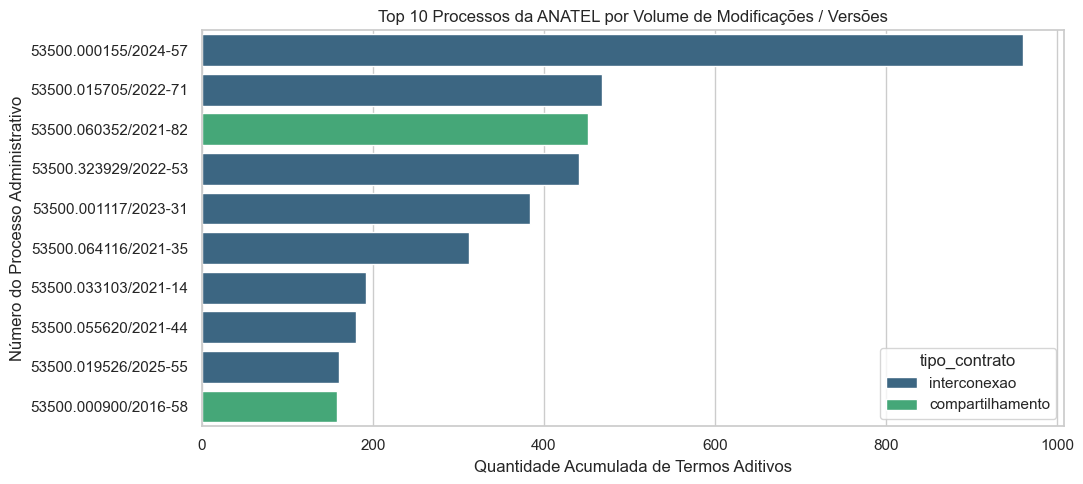

In [ ]:
query_9 = """
SELECT c.id_processo, c.tipo_contrato, COUNT(v.id_versao) AS total_versoes 
FROM contrato c 
INNER JOIN versao_contrato v ON c.id_contrato = v.id_contrato 
GROUP BY c.id_contrato 
ORDER BY total_versoes DESC 
LIMIT 10;
"""
df_9 = executar_consulta(query_9, "TOP 10 PROCESSOS COM MAIS ADITIVOS")
display(df_9)

# Plotagem Gráfica para a Seção 6 do Relatório
plt.figure(figsize=(11, 5))
sns.barplot(data=df_9, x='total_versoes', y='id_processo', hue='tipo_contrato', palette='viridis', dodge=False)
plt.title('Top 10 Processos da ANATEL por Volume de Modificações / Versões')
plt.xlabel('Quantidade Acumulada de Termos Aditivos')
plt.ylabel('Número do Processo Administrativo')
plt.tight_layout()
plt.show()

### Consulta 10: Índice de Concentração de Mercado em Compartilhamento Passivo
**Descrição:** Executa um agrupamento por empresa e calcula o volume total de participações contratuais vigentes na modalidade de compartilhamento de infraestrutura, expondo os principais players do setor.


==================== CONCENTRAÇÃO DE MERCADO - COMPARTILHAMENTO ====================



,empresa,total_participacoes
0,CEMIG DISTRIBUIÇÃO S.A.,1514
1,COPEL DISTRIBUIÇÃO S.A.,1377
2,COMPANHIA ENERGÉTICA DO CEARÁ - COELCE,630
3,ELETROPAULO METROPOLITANA ELETRICIDADE DE SÃO ...,493
4,CELESC DISTRIBUIÇÃO S.A.,384
5,COMPANHIA PAULISTA DE FORÇA E LUZ - CPFL,263
6,CELG DISTRIBUIÇÃO S.A - CELG D,250
7,AMPLA ENERGIA E SERVIÇOS S.A.,249
8,COMPANHIA ENERGÉTICA DE PERNAMBUCO - CELPE,235
9,COMPANHIA PAULISTA DE FORÇA E LUZ - CPFL (MATRIZ),217


C:\Users\co275\AppData\Local\Temp\ipykernel_13772\1606509584.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_10, x='total_participacoes', y='empresa', palette='magma')


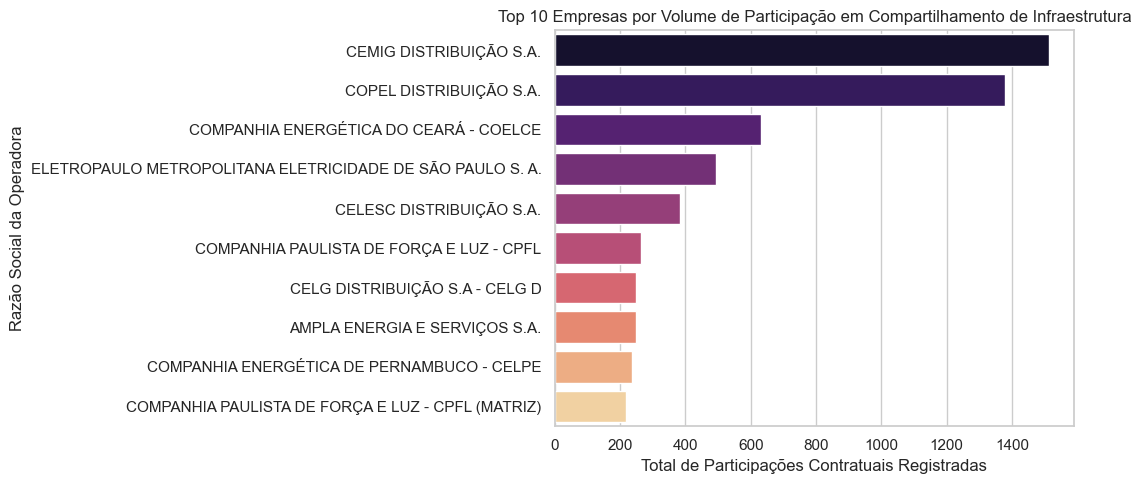

In [ ]:
query_10 = """
SELECT e.razao_social AS empresa, COUNT(p.id_participacao) AS total_participacoes 
FROM empresa e 
INNER JOIN participacao p ON e.id_empresa = p.id_empresa 
INNER JOIN versao_contrato v ON p.id_versao = v.id_versao 
INNER JOIN contrato c ON v.id_contrato = c.id_contrato 
WHERE c.tipo_contrato = 'compartilhamento'
GROUP BY e.id_empresa 
ORDER BY total_participacoes DESC 
LIMIT 10;
"""
df_10 = executar_consulta(query_10, "CONCENTRAÇÃO DE MERCADO - COMPARTILHAMENTO")
display(df_10)

# Plotagem Gráfica para a Seção 6 do Relatório
plt.figure(figsize=(11, 5))
sns.barplot(data=df_10, x='total_participacoes', y='empresa', palette='magma')
plt.title('Top 10 Empresas por Volume de Participação em Compartilhamento de Infraestrutura')
plt.xlabel('Total de Participações Contratuais Registradas')
plt.ylabel('Razão Social da Operadora')
plt.tight_layout()
plt.show()

# Seção 7

**Gabriel Veloso, 2024421649:**

Fiquei responsável pelo desenvolvimento da aplicação em Streamlit, criando as visualizações e a interface para exploração dos dados. Também participei da escolha do conjunto de dados utilizado no trabalho, pesquisando opções que atendessem aos requisitos da disciplina.

**Victoria Reis, 2020104630:** 

Fiquei responsável na preparação e tratamento dos dados, realizando processos de limpeza, transformação e validação das informações para garantir sua qualidade e confiabilidade. Também participei da modelagem do banco de dados, contribuindo para a construção dos Diagramas Entidade-Relacionamento (ER) e Relacional, apoiando a definição da estrutura lógica do sistema.
Fui responsável pela implementação do banco de dados e pela criação de sua estrutura física, incluindo tabelas, relacionamentos e restrições de integridade. 